<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/notebooks/Pothole_yolo11s_v2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Pothole Detection AI — Training Notebook
### Built on YOLO11 | Chepalungu + RDD2020 Datasets

---

This notebook trains an AI model to detect potholes in road images.
It is designed so that:
- ✅ You can stop and resume training at any time without losing progress
- ✅ Every cell explains what it does before running
- ✅ Problems are caught early before you waste time
- ✅ All results are saved to Google Drive automatically

## 🗺️ Notebook Map

| Section | What It Does |
|---|---|
| 0. Setup | Install packages, load keys, mount Drive |
| 1. Pre-Flight Checks | Verify GPU, keys, Drive BEFORE running |
| 2. Download Data | Get Chepalungu + RDD2020 datasets |
| 3. Prepare Data | Convert formats, clean labels, merge |
| 4. Train | Train YOLO11 with auto-save to Drive |
| 5. Resume | How to continue if Colab disconnects |
| 6. Evaluate | See accuracy numbers and charts |
| 7. Test | Run on new images and see detections |

## ⚠️ One Rule
**Run cells from top to bottom, one at a time.
Never skip a cell. Each one builds on the previous.**





In [35]:
# ============================================================
# SECTION 0: INSTALL PACKAGES AND LOAD UTILITIES
# ============================================================
#
# What this cell does, in order:
#   1. Installs the Python packages we need
#   2. Downloads our helper code from GitHub (utils.py)
#   3. VERIFIES that download actually worked (this is the
#      part that kept failing silently before)
#   4. Loads every helper function into memory
#   5. Sets HOME — the base folder every other cell uses
#   6. Confirms the GPU/CPU status
#
# IMPORTANT: If ANY step below prints a ❌, STOP. Do not run
# any other cell until you fix that ❌ and re-run this cell
# from the top. Every later section depends on this one
# finishing completely.
# ============================================================

import os

print("=" * 60)
print("STEP 1/5 — Installing packages (takes ~60 seconds)")
print("=" * 60)
get_ipython().run_line_magic(
    'pip', 'install "ultralytics<=8.3.40" supervision roboflow kaggle pyyaml -q'
)
print("✅ Packages installed\n")

print("=" * 60)
print("STEP 2/5 — Downloading utils.py from GitHub")
print("=" * 60)

GITHUB_USERNAME = "mwangikabacho254"   # ← this is already set correctly for you
UTILS_URL = f"https://raw.githubusercontent.com/{GITHUB_USERNAME}/pothole-utils/main/utils.py"

os.chdir("/content")
exit_code = os.system(f"wget -q {UTILS_URL} -O utils.py")

if not os.path.exists("utils.py"):
    raise RuntimeError(
        "❌ utils.py did not download at all. Check your internet "
        "connection and that the GitHub repo 'pothole-utils' is Public."
    )

with open("utils.py") as f:
    content = f.read()

if len(content) < 500 or "404" in content[:200] or "<html" in content[:200].lower():
    raise RuntimeError(
        f"❌ utils.py downloaded but looks wrong (size={len(content)} bytes).\n"
        f"   URL used: {UTILS_URL}\n"
        f"   Go check that this URL opens correctly in a browser tab."
    )

if "def run_all_checks" not in content:
    raise RuntimeError(
        "❌ utils.py downloaded but is missing expected functions.\n"
        "   Your GitHub file may be outdated — recopy the full utils.py "
        "content into your GitHub repo and commit again."
    )

print(f"✅ utils.py downloaded correctly ({len(content)} bytes)\n")

print("=" * 60)
print("STEP 3/5 — Loading utility functions into memory")
print("=" * 60)

import importlib
import sys

# Force a clean re-import even if an old broken version got cached earlier
if "utils" in sys.modules:
    del sys.modules["utils"]

import utils
importlib.reload(utils)
from utils import *

# Hard proof it actually worked — don't just trust the print statement
assert "run_all_checks" in globals(), "run_all_checks still not loaded — stop and ask for help."
assert "check_gpu" in globals(), "check_gpu still not loaded — stop and ask for help."
assert "clean_all_labels" in globals(), "clean_all_labels still not loaded — stop and ask for help."

print("✅ All utility functions confirmed loaded (run_all_checks, check_gpu, "
      "clean_all_labels, and others)\n")

print("=" * 60)
print("STEP 4/5 — Setting HOME directory")
print("=" * 60)
HOME = "/content"
os.chdir(HOME)
print(f"✅ HOME = {HOME}\n")

print("=" * 60)
print("STEP 5/5 — Checking software + hardware")
print("=" * 60)
os.system("yolo settings sync=False")

import ultralytics
ultralytics.checks()

import torch
if torch.cuda.is_available():
    print(f"\n✅ GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("\n⚠️  NO GPU DETECTED — you are running on CPU.")
    print("   Training will be extremely slow or may not work at all.")
    print("   FIX: Runtime → Change runtime type → T4 GPU → Save")
    print("   (This will restart your session — you'll need to re-run this cell after.)")

print("\n" + "=" * 60)
print("🎉 SECTION 0 COMPLETE — safe to continue to Section 0B")
print("=" * 60)

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 22.5/107.7 GB disk)

⚠️  NO GPU DETECTED — you are running on CPU.
   Training will be extremely slow or may not work at all.
   FIX: Runtime → Change runtime type → T4 GPU → Save
   (This will restart your session — you'll need to re-run this cell after.)

🎉 SECTION 0 COMPLETE — safe to continue to Section 0B


 ## Mount Google Drive

In [36]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
#
# WHY: Google Drive is your safety net.
# Colab sessions end after 12 hours (or if you close the tab).
# When that happens, everything in /content disappears.
# By saving to Drive, your trained model weights survive
# even if Colab shuts down mid-training.
#
# When you run this cell, a popup will ask you to sign in
# to Google. Click "Connect to Google Drive" and allow access.
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Create the folder structure on Drive
DRIVE_ROOT    = "/content/drive/MyDrive/PotholeAI"
DRIVE_RUNS    = f"{DRIVE_ROOT}/runs"
DRIVE_DATA    = f"{DRIVE_ROOT}/datasets"

os.makedirs(DRIVE_RUNS, exist_ok=True)
os.makedirs(DRIVE_DATA, exist_ok=True)

print("✅ Google Drive mounted")
print(f"   Your runs will be saved to: {DRIVE_RUNS}")
print(f"   Your datasets backed up to: {DRIVE_DATA}")

Mounted at /content/drive
✅ Google Drive mounted
   Your runs will be saved to: /content/drive/MyDrive/PotholeAI/runs
   Your datasets backed up to: /content/drive/MyDrive/PotholeAI/datasets


**Load API Keys**

In [37]:
# ============================================================
# LOAD API KEYS FROM COLAB SECRETS
# ============================================================
#
# API keys are like passwords. We NEVER type them directly
# into the notebook because:
#   - Someone could see them if you share the notebook
#   - They could end up in version history
#
# Instead we use Colab Secrets (the 🔑 icon in the left sidebar).
# If any key is missing, the cell will tell you exactly what to add.
#
# HOW TO ADD A SECRET:
#   1. Click the 🔑 key icon in the left sidebar
#   2. Click "+ Add new secret"
#   3. Type the Name exactly as shown below
#   4. Paste your key as the Value
#   5. Toggle "Notebook access" to ON
#
# Required secrets:
#   ROBOFLOW_API_KEY  → roboflow.com → Settings → Roboflow API → Copy
#   KAGGLE_USERNAME   → your Kaggle username (shown on kaggle.com/me)
#   KAGGLE_KEY        → kaggle.com → Settings → API → Create New Token
#                       open kaggle.json, copy the "key" value only
# ============================================================

from google.colab import userdata
import json

# Load Roboflow key
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
print("✅ Roboflow API key loaded")

# Load Kaggle credentials and write to the location Kaggle CLI expects
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY      = userdata.get('KAGGLE_KEY')

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.system("chmod 600 /root/.kaggle/kaggle.json")

print(f"✅ Kaggle API key configured — username: {KAGGLE_USERNAME}")
print("\n🎉 All keys loaded. You are ready to continue.")

✅ Roboflow API key loaded
✅ Kaggle API key configured — username: Mwangi kabacho

🎉 All keys loaded. You are ready to continue.


**Pre-Flight Checks**

In [ ]:
# ============================================================
# SECTION 1: PRE-FLIGHT CHECKS
# ============================================================
#
# This is like a pilot's checklist before takeoff.
# We verify EVERYTHING is working BEFORE downloading
# or processing any data.
#
# If anything is RED (❌), fix it before running Section 2.
# The cell tells you exactly what to fix.
#
# Checks performed:
#   ✅ GPU is T4 (needed for fast training)
#   ✅ All 3 API keys are available
#   ✅ Google Drive is mounted (for saving weights)
# ============================================================

print("Running pre-flight checks...\n")
all_ok = run_all_checks()

if all_ok:
    print("\n🚀 All systems go. Proceed to Section 2.")
else:
    print("\n🛑 Fix the issues above, then re-run this cell.")
    print("   Do NOT continue to Section 2 until all checks pass.")

**Download Chepalungu Dataset**

In [26]:
# ============================================================
# SECTION 2A: DOWNLOAD CHEPALUNGU DATASET
# ============================================================
#
# The Chepalungu dataset contains photos of potholes taken
# on Kenyan roads. It was collected specifically for this project.
# It is stored in Roboflow (a dataset management platform).
#
# The Roboflow SDK downloads it directly into Colab
# in YOLO format — which means:
#   - Images in a folder called "images/"
#   - Labels in a folder called "labels/"
#   - Each label is a .txt file with one line per pothole
#
# This cell checks if the dataset already exists before
# downloading — so re-running the notebook won't re-download.
# ============================================================

from roboflow import Roboflow

CHEPALUNGU_DIR = f"{HOME}/datasets/chepalungu-1"

if os.path.exists(CHEPALUNGU_DIR):
    print(f"✅ Chepalungu dataset already downloaded at: {CHEPALUNGU_DIR}")
    print("   Skipping download.")
else:
    print("⬇️  Downloading Chepalungu dataset from Roboflow...")
    rf         = Roboflow(api_key=ROBOFLOW_API_KEY)
    ws         = rf.workspace("nipemacho")
    project    = ws.project("chepalungu")
    version    = project.version(1)

    os.makedirs(f"{HOME}/datasets", exist_ok=True)
    os.chdir(f"{HOME}/datasets")

    dataset    = version.download("yolov11")
    CHEPALUNGU_DIR = dataset.location
    print(f"✅ Downloaded to: {CHEPALUNGU_DIR}")

# Show what we got
print("\n📦 Chepalungu dataset contents:")
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(CHEPALUNGU_DIR, split, 'images')
    if os.path.exists(img_dir):
        n = len(os.listdir(img_dir))
        print(f"   {split:>5}: {n} images")

os.chdir(HOME)

⬇️  Downloading Chepalungu dataset from Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov11:: 100%|██████████| 527/527 [00:00<00:00, 4651.17it/s]

✅ Downloaded to: /content/datasets/chepalungu-1

📦 Chepalungu dataset contents:
   train: 183 images
   valid: 52 images
    test: 26 images


**Download RDD2020 Dataset**

In [27]:
# ============================================================
# SECTION 2B: DOWNLOAD RDD2020 DATASET
# ============================================================
#
# RDD2020 = Road Damage Detection 2020
# This is a large international dataset with road damage images
# from Japan, India, and Czech Republic.
#
# WHY we use it:
#   The Chepalungu dataset has ~260 images.
#   RDD2020 adds 6,000+ more diverse images.
#   More images = better model.
#
# The RDD2020 dataset uses XML annotations (Pascal VOC format).
# In Section 3 we will convert them to YOLO format.
#
# This is a 1.4GB download. It checks if already downloaded.
# On Colab's fast connection it takes ~20 seconds.
# ============================================================

RDD_DIR  = "/content/rdd2020"
RDD_ZIP  = "/content/rdd2020.zip"

if os.path.exists(RDD_DIR) and os.listdir(RDD_DIR):
    print(f"✅ RDD2020 already downloaded at: {RDD_DIR}")
    print("   Skipping download.")
else:
    print("⬇️  Downloading RDD2020 dataset from Kaggle (1.4GB)...")
    print("   This takes about 20 seconds on Colab's connection.")
    os.makedirs(RDD_DIR, exist_ok=True)
    os.system(f"kaggle datasets download -d ziedkelboussi/rdd2020-dataset "
              f"-p {RDD_DIR} --unzip")
    print("✅ RDD2020 downloaded and extracted")

# Show folder structure
print("\n📦 RDD2020 folder structure:")
for country in ['Czech', 'India', 'Japan']:
    xml_dir = f"{RDD_DIR}/train/{country}/annotations/xmls"
    img_dir = f"{RDD_DIR}/train/{country}/images"
    if os.path.exists(xml_dir):
        n_xml = len(list(Path(xml_dir).glob('*.xml')))
        n_img = len(list(Path(img_dir).glob('*.jpg')))
        print(f"   {country}: {n_img} images, {n_xml} annotations")
    else:
        print(f"   {country}: ⚠️  folder not found")

⬇️  Downloading RDD2020 dataset from Kaggle (1.4GB)...
   This takes about 20 seconds on Colab's connection.
✅ RDD2020 downloaded and extracted

📦 RDD2020 folder structure:
   Czech: 2829 images, 2829 annotations
   India: 7706 images, 7706 annotations
   Japan: 10506 images, 10506 annotations


**Convert RDD2020 XML to YOLO**

In [28]:
# ============================================================
# SECTION 3A: CONVERT RDD2020 ANNOTATIONS TO YOLO FORMAT
# ============================================================
#
# The RDD2020 dataset labels damage in 10 categories:
#   D00, D01, D10, D11, D20, D40, D43, D44, D50, D0w0
#
# We only want potholes. In RDD2020, potholes = D40.
# We will:
#   1. Read each XML file
#   2. Keep ONLY annotations labelled "D40"
#   3. Convert the bounding box to YOLO format
#   4. Save as .txt files in a "labels" folder next to "images"
#
# After this, both Chepalungu AND RDD2020 will be in the same
# YOLO format, ready to be merged.
# ============================================================

print("Converting RDD2020 XML annotations → YOLO format")
print("Keeping only D40 (pothole) class\n")

TARGET_CLASS = "D40"
total_positive = 0
total_negative = 0

for country in ['Czech', 'India', 'Japan']:
    xml_dir = f"{RDD_DIR}/train/{country}/annotations/xmls"
    lbl_dir = f"{RDD_DIR}/train/{country}/labels"

    if not os.path.exists(xml_dir):
        print(f"⚠️  {country}: no annotations folder, skipping")
        continue

    converted, _, boxes = convert_xml_folder_to_yolo(
        xml_dir   = xml_dir,
        img_dir   = f"{RDD_DIR}/train/{country}/images",
        out_dir   = lbl_dir,
        target_classes = [TARGET_CLASS],
        class_id  = 0
    )

    # Count positives (files with at least one box)
    positives = sum(
        1 for f in Path(lbl_dir).glob('*.txt')
        if open(f).read().strip()
    )
    negatives = converted - positives
    total_positive += positives
    total_negative += negatives
    print(f"   {country}: {positives} with potholes, {negatives} without")

print(f"\n✅ Total: {total_positive} images with potholes")
print(f"   (The {total_negative} images without are kept as background)")

Converting RDD2020 XML annotations → YOLO format
Keeping only D40 (pothole) class

  Converted 2829 XML files → 197 YOLO boxes
   Czech: 154 with potholes, 2675 without
  Converted 7706 XML files → 3187 YOLO boxes
   India: 1530 with potholes, 6176 without
  Converted 10506 XML files → 2243 YOLO boxes
   Japan: 1390 with potholes, 9116 without

✅ Total: 3074 images with potholes
   (The 17967 images without are kept as background)


**Clean All Labels**

In [29]:
# ============================================================
# SECTION 3B: CLEAN ALL LABEL FILES
# ============================================================
#
# Why do we need to clean labels?
#
# The Chepalungu dataset was annotated using polygons in Roboflow.
# Polygons look like: 0 x1 y1 x2 y2 x3 y3 x4 y4 ...
# YOLO needs bounding boxes: 0 cx cy w h  (exactly 5 values)
#
# If we skip this step, YOLO silently ignores polygon lines
# during training — which is why you were getting 324 images
# instead of 6000+. The images were there but the annotations
# were being ignored.
#
# This cell:
#   - Converts every polygon line to a bounding box
#   - Forces all class IDs to 0 (single class: pothole)
#   - Removes any lines that are genuinely corrupt
# ============================================================

print("Cleaning Chepalungu labels (fixing polygons → boxes)...")
chep_stats = clean_all_labels(CHEPALUNGU_DIR, force_class=0)

print("\nCleaning RDD2020 labels (ensuring consistent format)...")
rdd_stats = clean_all_labels(RDD_DIR, force_class=0)

print(f"\n✅ Label cleaning complete")
print(f"   Chepalungu: {chep_stats['fixed_polygons']} polygon lines converted")
print(f"   RDD2020:    {rdd_stats['fixed_polygons']} polygon lines converted")

Cleaning Chepalungu labels (fixing polygons → boxes)...
  Files cleaned       : 263
  Total boxes kept    : 495
  Polygon lines fixed : 500

Cleaning RDD2020 labels (ensuring consistent format)...
  Files cleaned       : 21041
  Total boxes kept    : 5627
  Polygon lines fixed : 0

✅ Label cleaning complete
   Chepalungu: 500 polygon lines converted
   RDD2020:    0 polygon lines converted


**Build Combined Dataset**

In [30]:
# ============================================================
# SECTION 3C: BUILD COMBINED DATASET
# ============================================================
#
# Now we merge Chepalungu + RDD2020 into one unified dataset.
#
# For RDD2020 we balance the data first:
#   - Keep ALL positive images (have potholes): 3,074
#   - Keep 1 negative per positive (no potholes): ~3,074
#   - Total from RDD: ~6,148 selected from 21,000
#
# Then we split everything into:
#   - 80% training   (model learns from this)
#   - 10% validation (we check progress during training)
#   - 10% test       (final accuracy test, model never sees this)
#
# We add prefixes to filenames so there are no name collisions:
#   kenya_IMG_001.jpg   ← from Chepalungu
#   rdd_Czech_001.jpg   ← from RDD2020
# ============================================================

COMBINED_DIR = f"{HOME}/datasets/combined"

if os.path.exists(COMBINED_DIR) and os.path.exists(f"{COMBINED_DIR}/data.yaml"):
    print(f"✅ Combined dataset already exists at: {COMBINED_DIR}")
    print("   Skipping merge step.")
else:
    print("Building combined dataset from Chepalungu + RDD2020...\n")

    # ── Balance RDD2020 first ─────────────────────────────────
    # Keep all positives + equal number of negatives per country
    rdd_sources = []
    for country in ['Czech', 'India', 'Japan']:
        img_dir = f"{RDD_DIR}/train/{country}/images"
        lbl_dir = f"{RDD_DIR}/train/{country}/labels"
        if not os.path.exists(img_dir):
            continue

        positives = [f for f in Path(lbl_dir).glob('*.txt')
                     if open(f).read().strip()]
        negatives = [f for f in Path(lbl_dir).glob('*.txt')
                     if not open(f).read().strip()]

        # 1 negative per positive
        n_keep = min(len(negatives), len(positives))
        random.seed(42)
        kept_neg = random.sample(negatives, n_keep)

        selected = positives + kept_neg
        random.shuffle(selected)

        # Split 80/10/10
        n = len(selected)
        n_train = int(n * 0.8)
        n_val   = int(n * 0.1)
        splits  = {
            'train': selected[:n_train],
            'valid': selected[n_train:n_train+n_val],
            'test':  selected[n_train+n_val:]
        }

        for split, files in splits.items():
            dst_img = f"{COMBINED_DIR}/{split}/images"
            dst_lbl = f"{COMBINED_DIR}/{split}/labels"
            os.makedirs(dst_img, exist_ok=True)
            os.makedirs(dst_lbl, exist_ok=True)
            for lbl_path in files:
                stem = lbl_path.stem
                img_src = f"{img_dir}/{stem}.jpg"
                if not os.path.exists(img_src):
                    continue
                prefix = country.lower()
                shutil.copy(img_src,
                            f"{dst_img}/{prefix}_{stem}.jpg")
                shutil.copy(str(lbl_path),
                            f"{dst_lbl}/{prefix}_{stem}.txt")

        total = len(selected)
        print(f"  {country}: {len(positives)} positive + {n_keep} negative = {total} selected")

    # ── Copy Chepalungu into combined ─────────────────────────
    print("\n  Adding Chepalungu (Kenya) images:")
    for split, dst_split in [('train','train'),('valid','valid'),('test','test')]:
        src_img = f"{CHEPALUNGU_DIR}/{split}/images"
        src_lbl = f"{CHEPALUNGU_DIR}/{split}/labels"
        dst_img = f"{COMBINED_DIR}/{dst_split}/images"
        dst_lbl = f"{COMBINED_DIR}/{dst_split}/labels"
        n = copy_split(src_img, src_lbl, dst_img, dst_lbl, prefix='kenya')
        print(f"    {split}: {n} images")

    # ── Write data.yaml with ABSOLUTE paths ───────────────────
    import yaml
    yaml_path = f"{COMBINED_DIR}/data.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump({
            'train': f"{COMBINED_DIR}/train/images",
            'val':   f"{COMBINED_DIR}/valid/images",
            'test':  f"{COMBINED_DIR}/test/images",
            'nc':    1,
            'names': ['pothole']
        }, f)
    print(f"\n✅ data.yaml written with absolute paths")

# ── Always verify counts ─────────────────────────────────────
print("\nFinal dataset totals:")
for split in ['train', 'valid', 'test']:
    img_dir = f"{COMBINED_DIR}/{split}/images"
    lbl_dir = f"{COMBINED_DIR}/{split}/labels"
    if os.path.exists(img_dir):
        n_img = len(os.listdir(img_dir))
        n_lbl = len(os.listdir(lbl_dir))
        print(f"  {split:>5}: {n_img} images, {n_lbl} labels")

Building combined dataset from Chepalungu + RDD2020...

  Czech: 154 positive + 154 negative = 308 selected
  India: 1530 positive + 1530 negative = 3060 selected
  Japan: 1390 positive + 1390 negative = 2780 selected

  Adding Chepalungu (Kenya) images:
    train: 183 images
    valid: 52 images
    test: 26 images

✅ data.yaml written with absolute paths

Final dataset totals:
  train: 5101 images, 5101 labels
  valid: 666 images, 666 labels
   test: 642 images, 642 labels


**Final Integrity Check**

In [30]:
# ============================================================
# SECTION 3D: FINAL DATA INTEGRITY CHECK
# ============================================================
#
# Before we start training (which takes 30-40 minutes),
# we do one final check on the combined dataset.
#
# This confirms:
#   ✅ data.yaml paths are correct and exist
#   ✅ Image and label counts match
#   ✅ Total bounding boxes are sensible
#
# If you see large numbers here (5000+ training images),
# the merge worked correctly.
# If you see small numbers (300-400), something went wrong
# — stop and re-run Section 3C.
# ============================================================

DATA_YAML = f"{COMBINED_DIR}/data.yaml"

print("Running final dataset integrity check...\n")
ok = check_dataset(COMBINED_DIR)

# Show the data.yaml so you can see the paths are absolute
print("\n=== Contents of data.yaml ===")
with open(DATA_YAML) as f:
    print(f.read())

if ok:
    print("✅ Dataset is clean and ready for training.")
    print("   Proceed to Section 4 to train the model.")
else:
    print("❌ Problems detected. Fix them before training.")

Running final dataset integrity check...

DATASET INTEGRITY CHECK
  ✅ train: 5101 images | 5101 labels | 4852 boxes
  ✅   val: 666 images | 666 labels | 687 boxes
  ✅  test: 642 images | 642 labels | 576 boxes
  Classes: 1 → ['pothole']

=== Contents of data.yaml ===
names:
- pothole
nc: 1
test: /content/datasets/combined/test/images
train: /content/datasets/combined/train/images
val: /content/datasets/combined/valid/images

✅ Dataset is clean and ready for training.
   Proceed to Section 4 to train the model.


**Train the Model**

In [31]:
# ============================================================
# TRAIN V2 — Fine-tune from V1 weights, save straight to Drive
# ============================================================
# This must run AFTER Steps 1–10 above in this same session
# (needs HOME, DRIVE_RUNS, COMBINED_DIR already defined).
# ============================================================

RUN_V1    = "pothole_yolo11s_v1"        # your completed V1 run
RUN_V2    = "pothole_yolo11s_v2"        # new run name
DATA_YAML = f"{COMBINED_DIR}/data.yaml"
BEST_V1   = f"{DRIVE_RUNS}/{RUN_V1}/weights/best.pt"

# Sanity check before we spend 30+ minutes training
assert os.path.exists(BEST_V1), f"❌ V1 weights not found at {BEST_V1} — stop and check Drive."
assert os.path.exists(DATA_YAML), f"❌ data.yaml not found at {DATA_YAML} — re-run Step 9/10."
print(f"✅ V1 weights found: {BEST_V1}")
print(f"✅ data.yaml found: {DATA_YAML}")

LOCAL_V1 = f"{HOME}/v1_best.pt"
shutil.copy(BEST_V1, LOCAL_V1)
print(f"✅ V1 weights copied locally to: {LOCAL_V1}")

os.chdir(HOME)
print(f"\n🚀 Starting V2 training — saving DIRECTLY to Drive at every save_period\n")

!yolo task=detect mode=train \
      model={LOCAL_V1} \
      data={DATA_YAML} \
      epochs=40 \
      imgsz=800 \
      batch=8 \
      patience=15 \
      optimizer=AdamW \
      lr0=0.001 \
      lrf=0.01 \
      warmup_epochs=2 \
      augment=True \
      hsv_h=0.015 \
      hsv_s=0.7 \
      hsv_v=0.4 \
      flipud=0.1 \
      fliplr=0.5 \
      mosaic=1.0 \
      plots=True \
      save=True \
      save_period=5 \
      project={DRIVE_RUNS} \
      name={RUN_V2}

print(f"\n✅ Training finished (or stopped). Weights live at: {DRIVE_RUNS}/{RUN_V2}/weights/")

✅ V1 weights found: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v1/weights/best.pt
✅ data.yaml found: /content/datasets/combined/data.yaml
✅ V1 weights copied locally to: /content/v1_best.pt

🚀 Starting V2 training — saving DIRECTLY to Drive at every save_period

New https://pypi.org/project/ultralytics/8.4.99 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/v1_best.pt, data=/content/datasets/combined/data.yaml, epochs=40, time=None, patience=15, batch=8, imgsz=800, save=True, save_period=5, cache=False, device=None, workers=8, project=/content/drive/MyDrive/PotholeAI/runs, name=pothole_yolo11s_v2, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, ove

**Resume After Disconnection**

In [4]:
# ============================================================
# V2 RESUME CHECK — run this if Colab disconnects during V2 training
# ============================================================
# Needs HOME, DRIVE_RUNS defined — re-run Steps 1-3 (setup/Drive/keys)
# first if this is a brand new session, then run this cell.
# ============================================================

import os

RUN_V2     = "pothole_yolo11s_v2"
RUN_V2_DIR = f"{DRIVE_RUNS}/{RUN_V2}"
last_pt_v2 = f"{RUN_V2_DIR}/weights/last.pt"

if os.path.exists(last_pt_v2):
    size_mb = os.path.getsize(last_pt_v2) / 1e6
    print(f"✅ Found V2 checkpoint: {last_pt_v2}")
    print(f"   File size: {size_mb:.1f} MB")
    print(f"\nTo resume training exactly where it stopped, run:")
    print(f"  !yolo task=detect mode=train resume=True model={last_pt_v2}")
else:
    print(f"❌ No V2 checkpoint found at: {last_pt_v2}")
    print("   Either training hasn't reached a save_period yet, or the run name is wrong.")
    print("   If this is the case, re-run the Train V2 cell from scratch.")

✅ Found V2 checkpoint: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v2/weights/last.pt
   File size: 19.2 MB

To resume training exactly where it stopped, run:
  !yolo task=detect mode=train resume=True model=/content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v2/weights/last.pt


**If it finds a checkpoint, run this in the next cell:**

In [ ]:
!yolo task=detect mode=train resume=True model={last_pt_v2}

**SESSION RECOVERY**

In [6]:
# ============================================================
# SESSION RECOVERY — Run this after any Colab disconnection
# ============================================================
import os, glob, yaml

# Restore basic variables
HOME         = "/content"
COMBINED_DIR = "/content/datasets/combined"
DRIVE_RUNS   = "/content/drive/MyDrive/PotholeAI/runs"
RUN_NAME     = "pothole_yolo11s_v1"
DATA_YAML    = f"{COMBINED_DIR}/data.yaml"

# Mount Drive to access saved weights
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("✅ Drive mounted")

# Point directly to the saved weights on Drive
# No need to re-download or re-train anything
BEST_PT  = f"{DRIVE_RUNS}/{RUN_NAME}/weights/best.pt"
RUN_DIR  = f"{DRIVE_RUNS}/{RUN_NAME}"

# Verify the weights file actually exists
if os.path.exists(BEST_PT):
    size_mb = os.path.getsize(BEST_PT) / 1e6
    print(f"✅ Model weights found: {BEST_PT}")
    print(f"   File size: {size_mb:.1f} MB")
    print(f"\n🎯 Your model results:")
    print(f"   mAP50      = 0.518  (51.8%)")
    print(f"   Precision  = 0.604  (60.4%)")
    print(f"   Recall     = 0.469  (46.9%)")
    print(f"\n✅ Ready to evaluate and run detections.")
else:
    print(f"❌ Weights not found at: {BEST_PT}")
    print(f"   Check Drive at: {DRIVE_RUNS}")

Mounted at /content/drive
✅ Drive mounted
✅ Model weights found: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v1/weights/best.pt
   File size: 19.2 MB

🎯 Your model results:
   mAP50      = 0.518  (51.8%)
   Precision  = 0.604  (60.4%)
   Recall     = 0.469  (46.9%)

✅ Ready to evaluate and run detections.


**Install Packages**

In [7]:
# Reinstall packages — required every new Colab session
%pip install "ultralytics<=8.3.40" supervision -q
!yolo settings sync=False

import ultralytics
ultralytics.checks()
print("✅ Packages ready")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.2/107.7 GB disk)
✅ Packages ready


**VIEW TRAINING CHARTS**


📊 Loss Curves + mAP over 60 Epochs


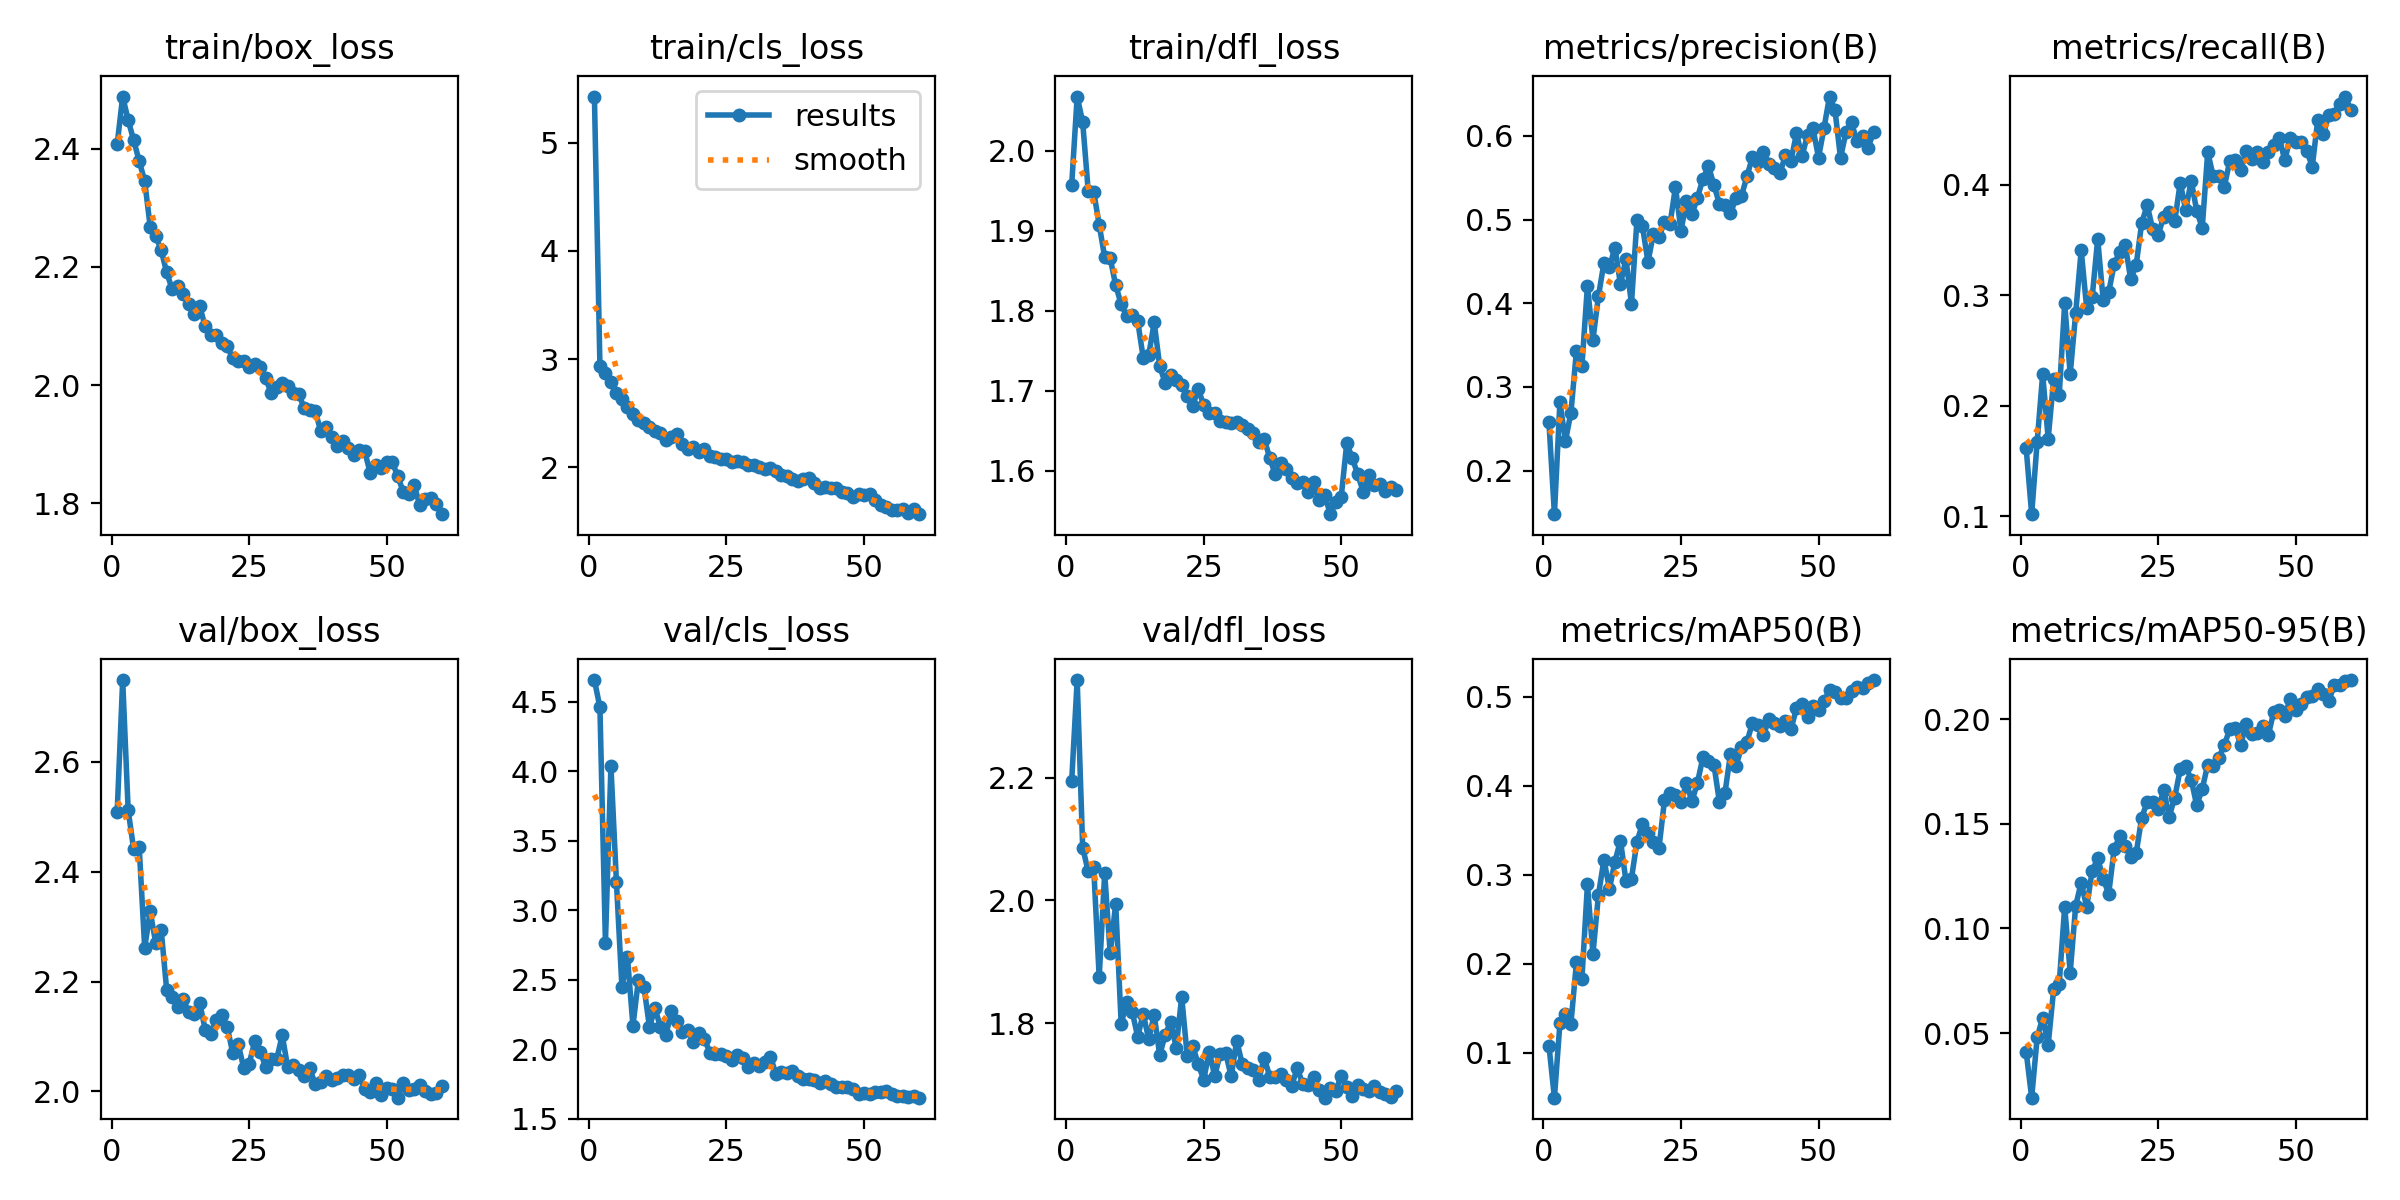


📊 Confusion Matrix


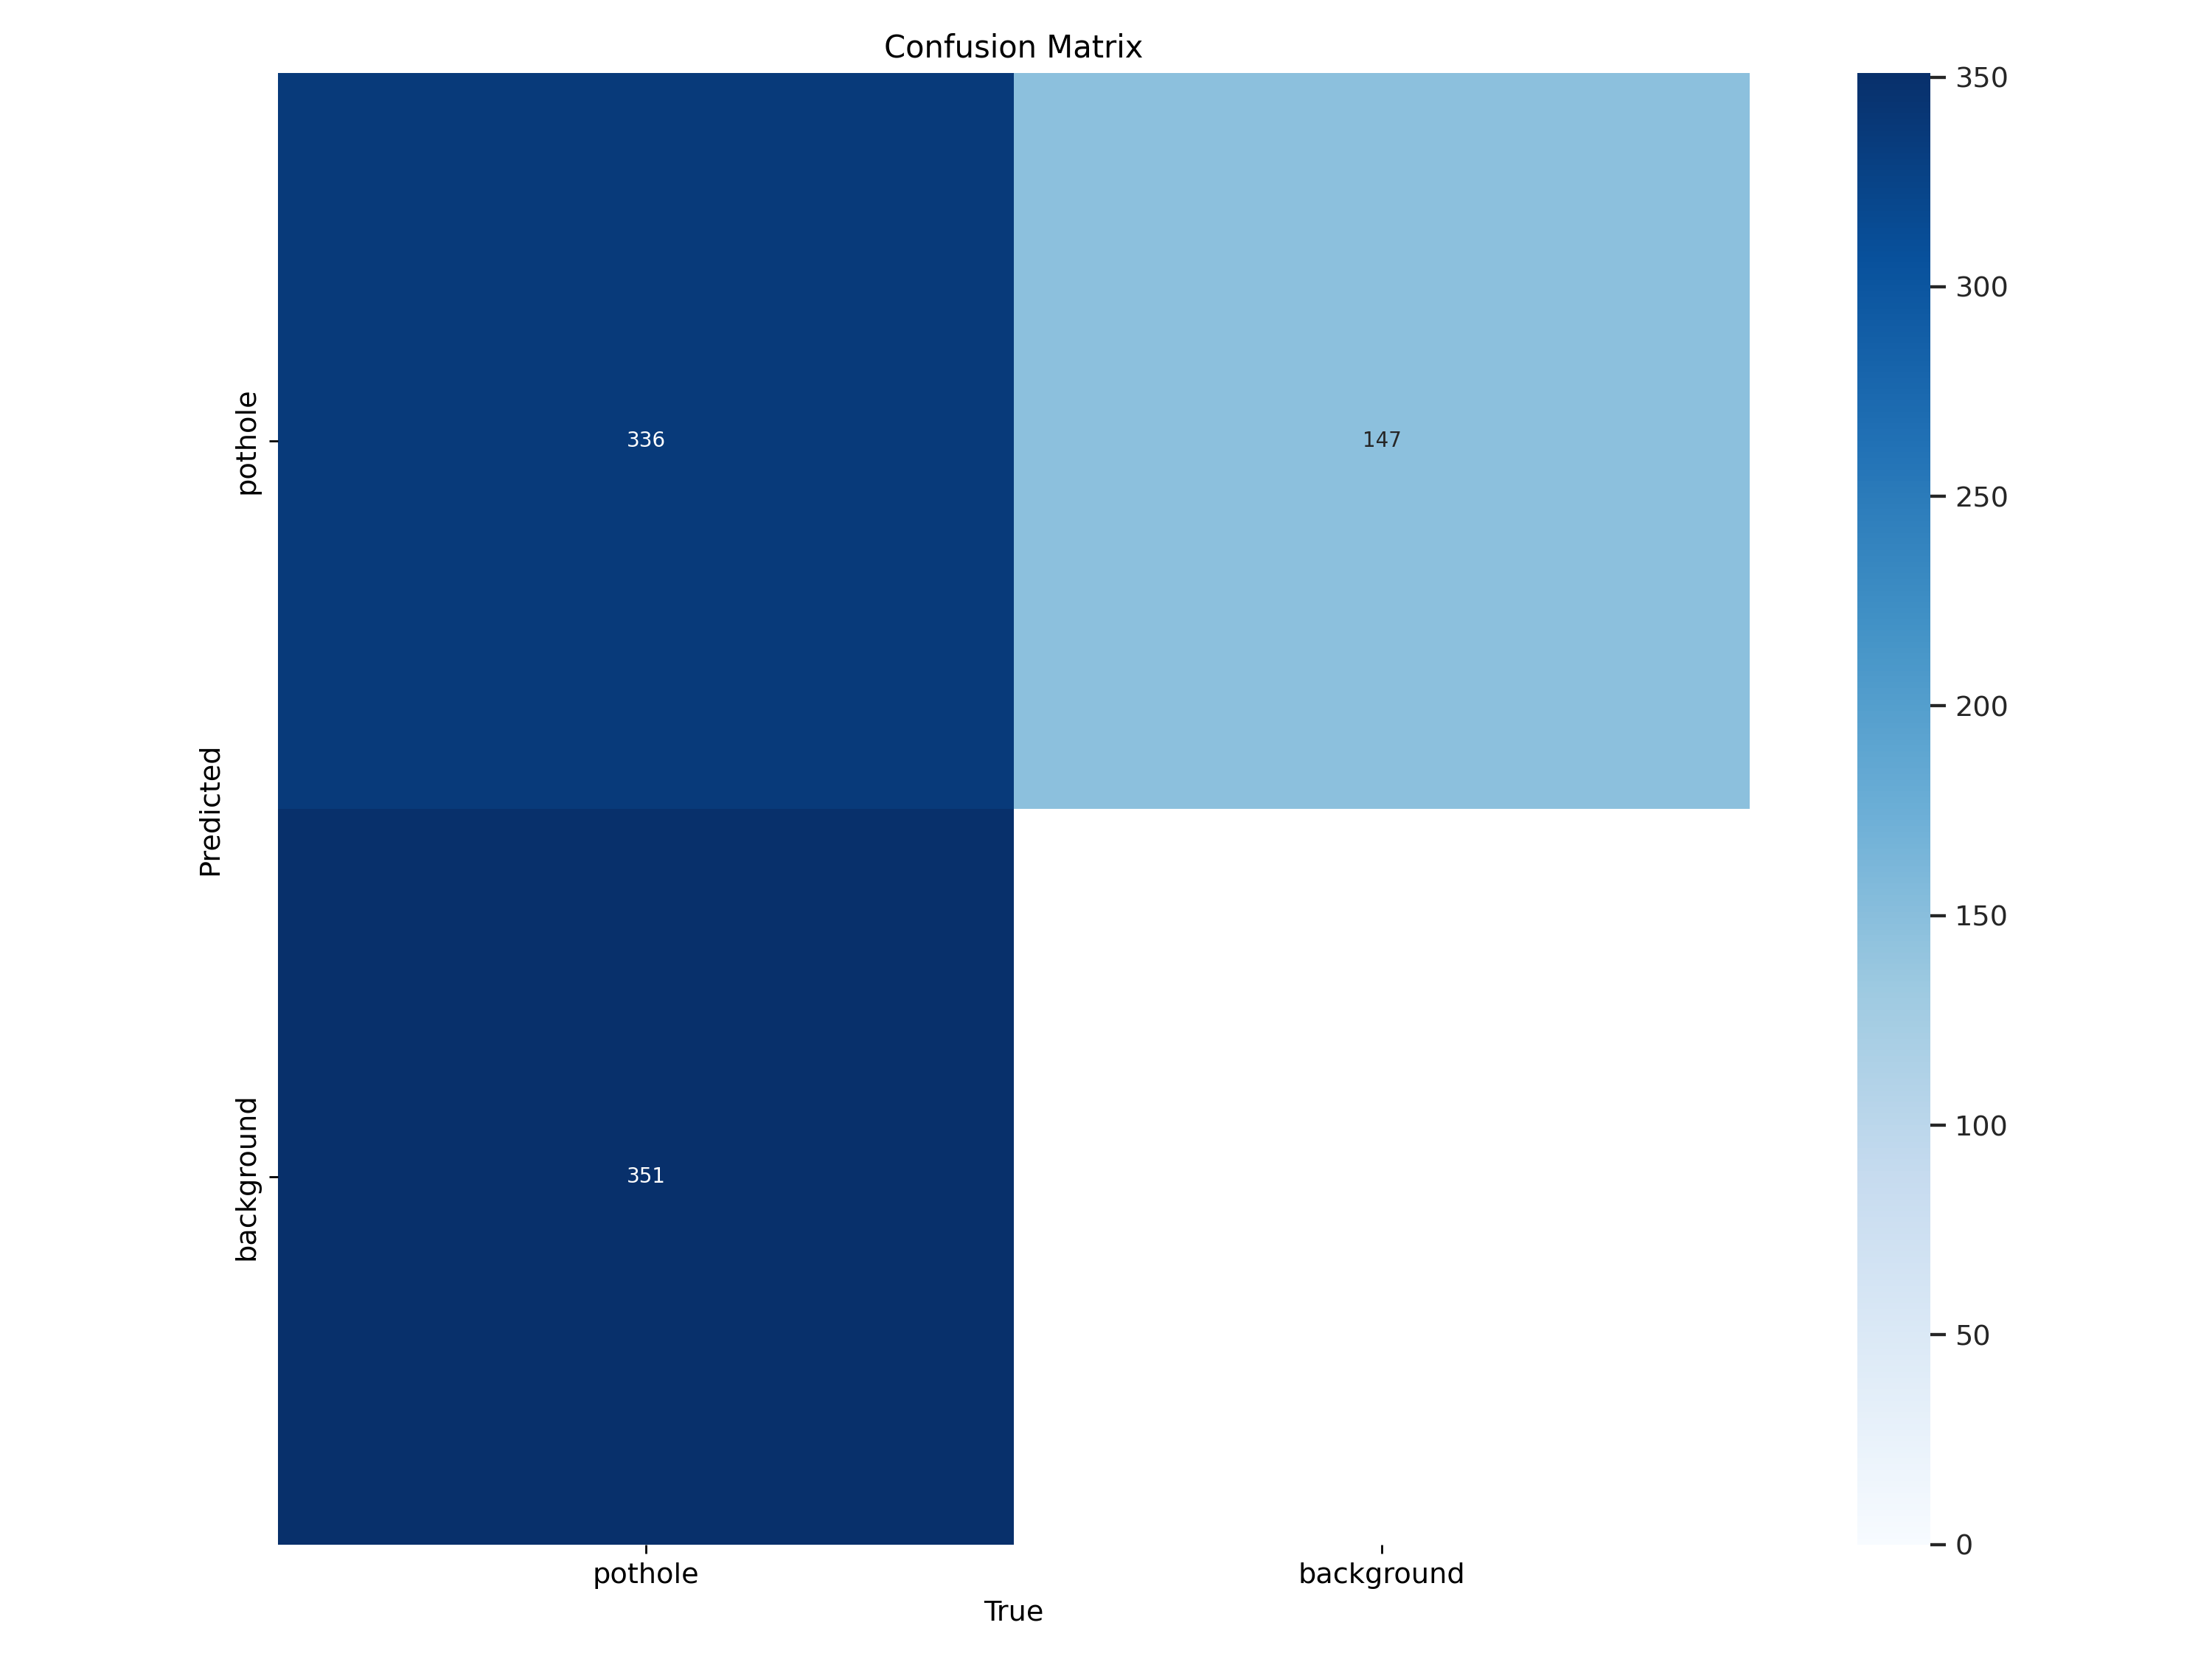


📊 Sample Validation Predictions


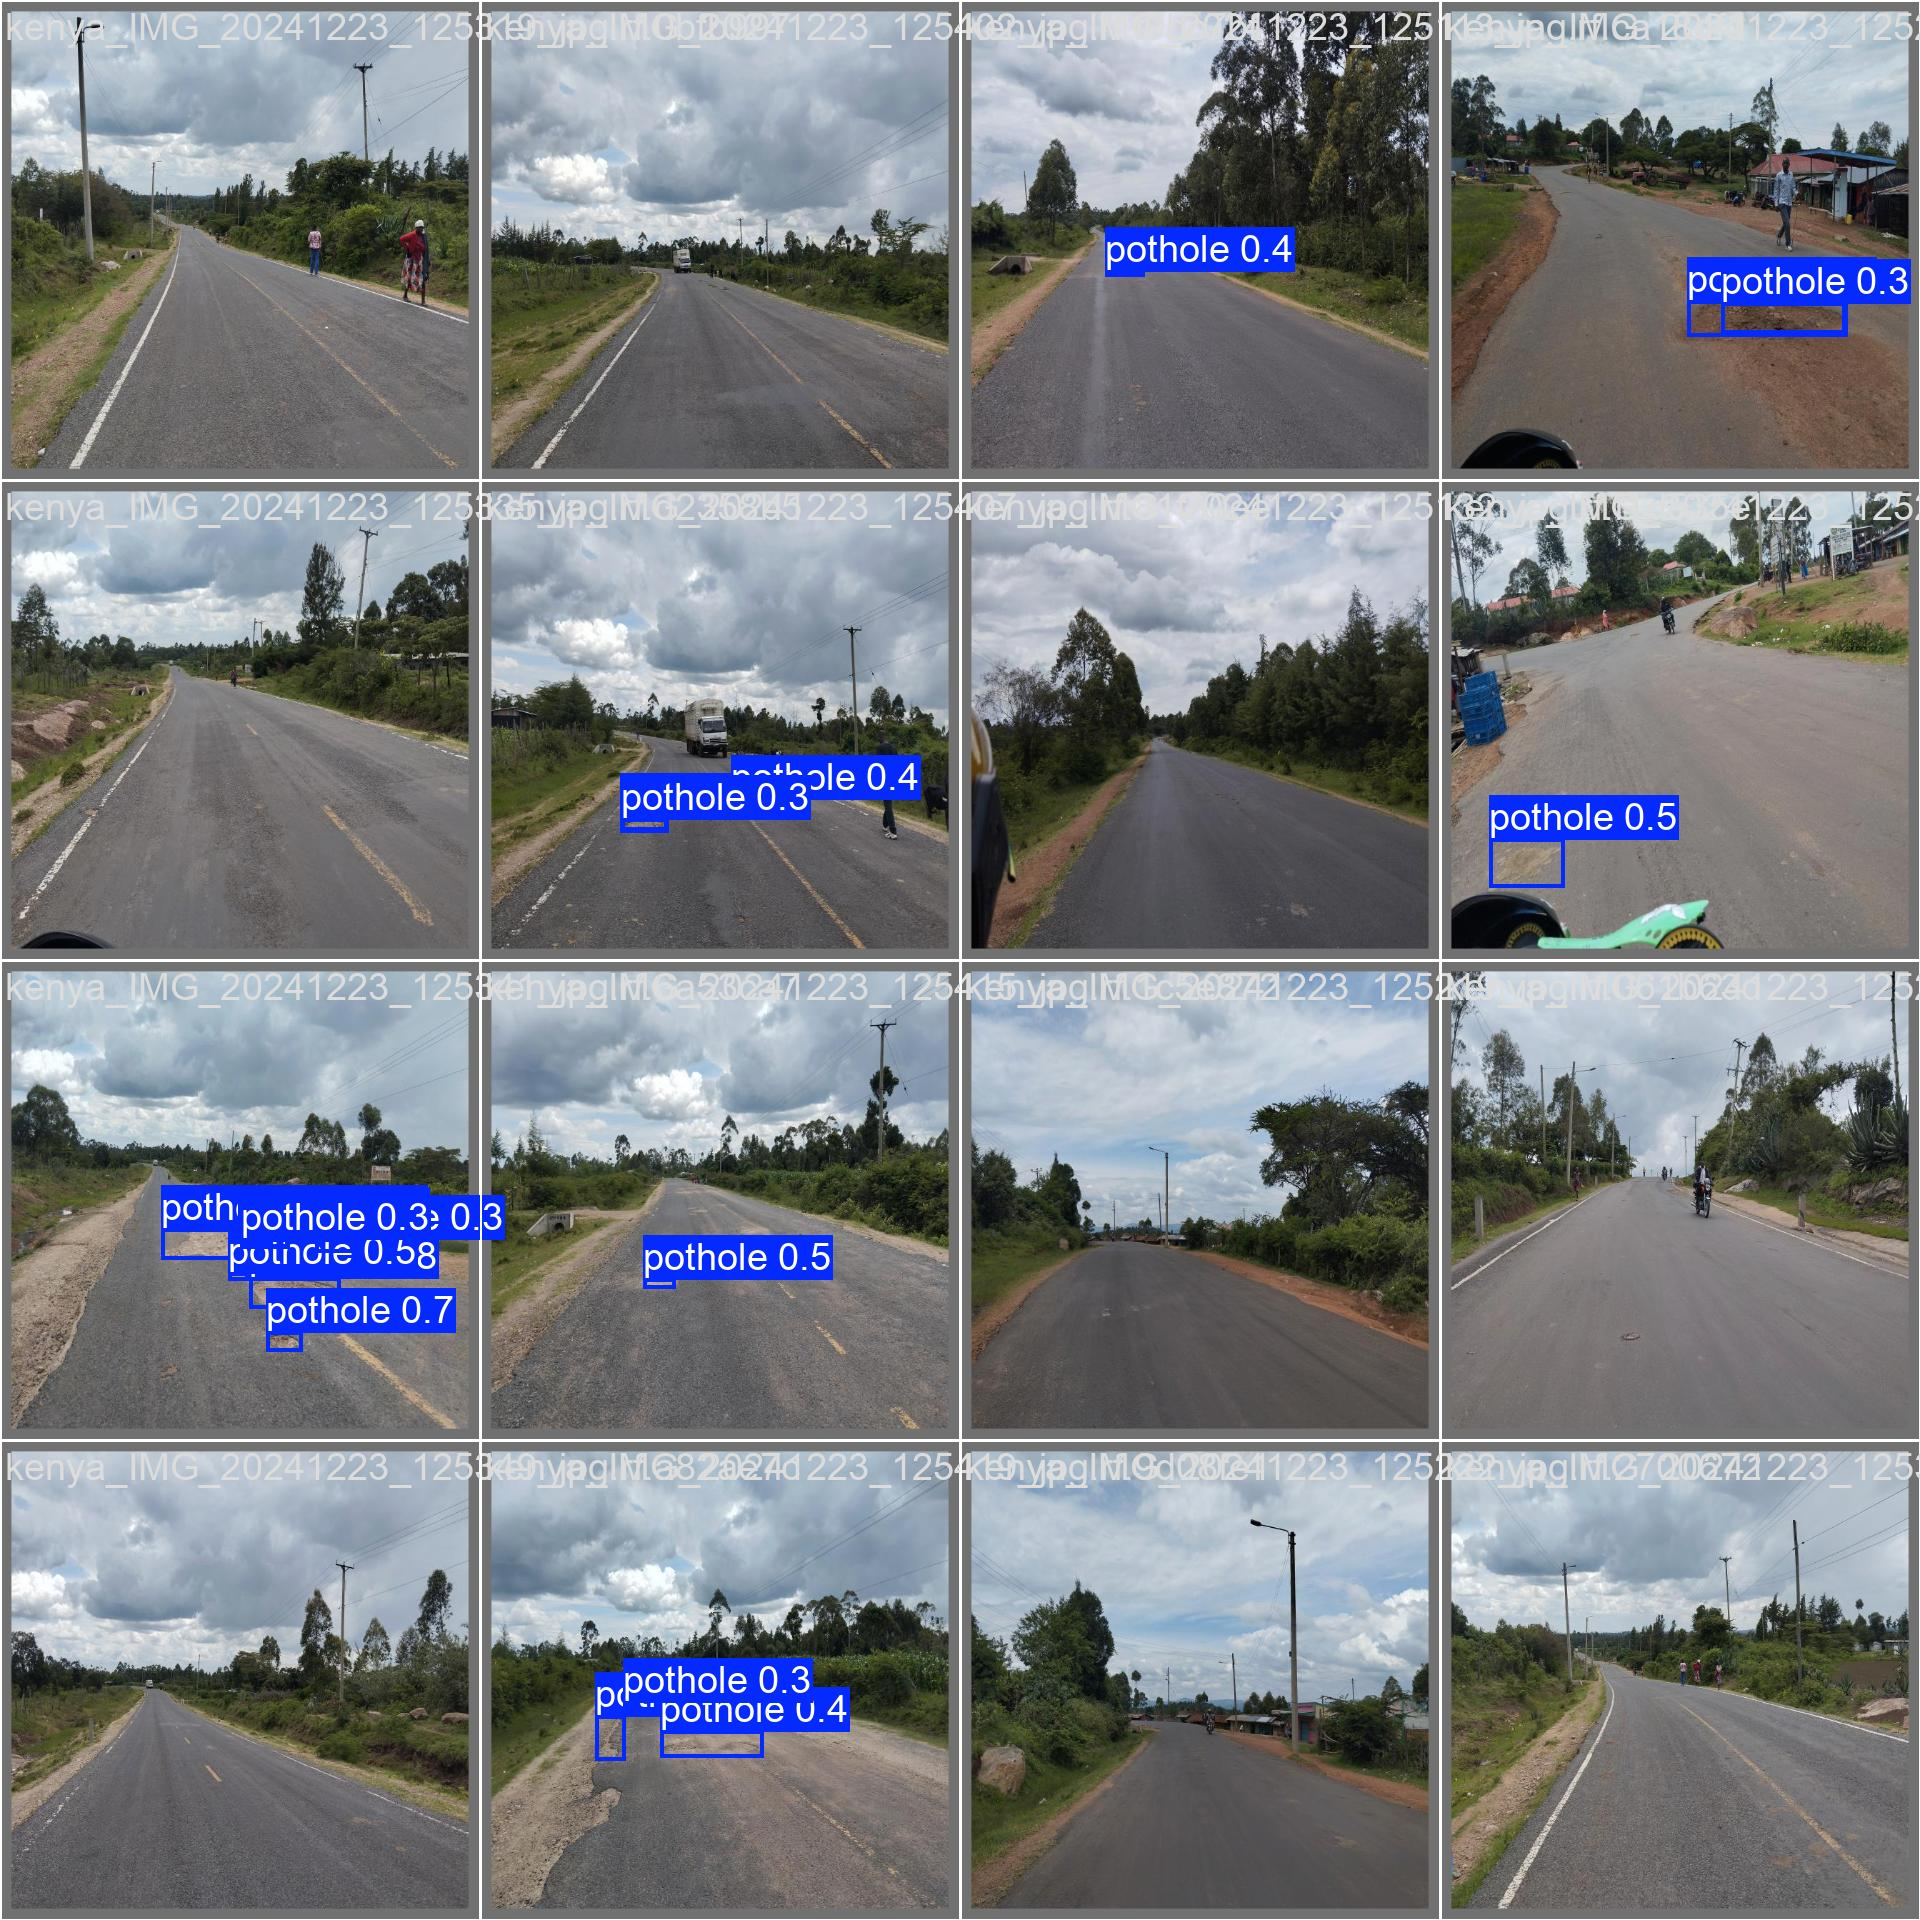


📊 Precision-Recall Curve


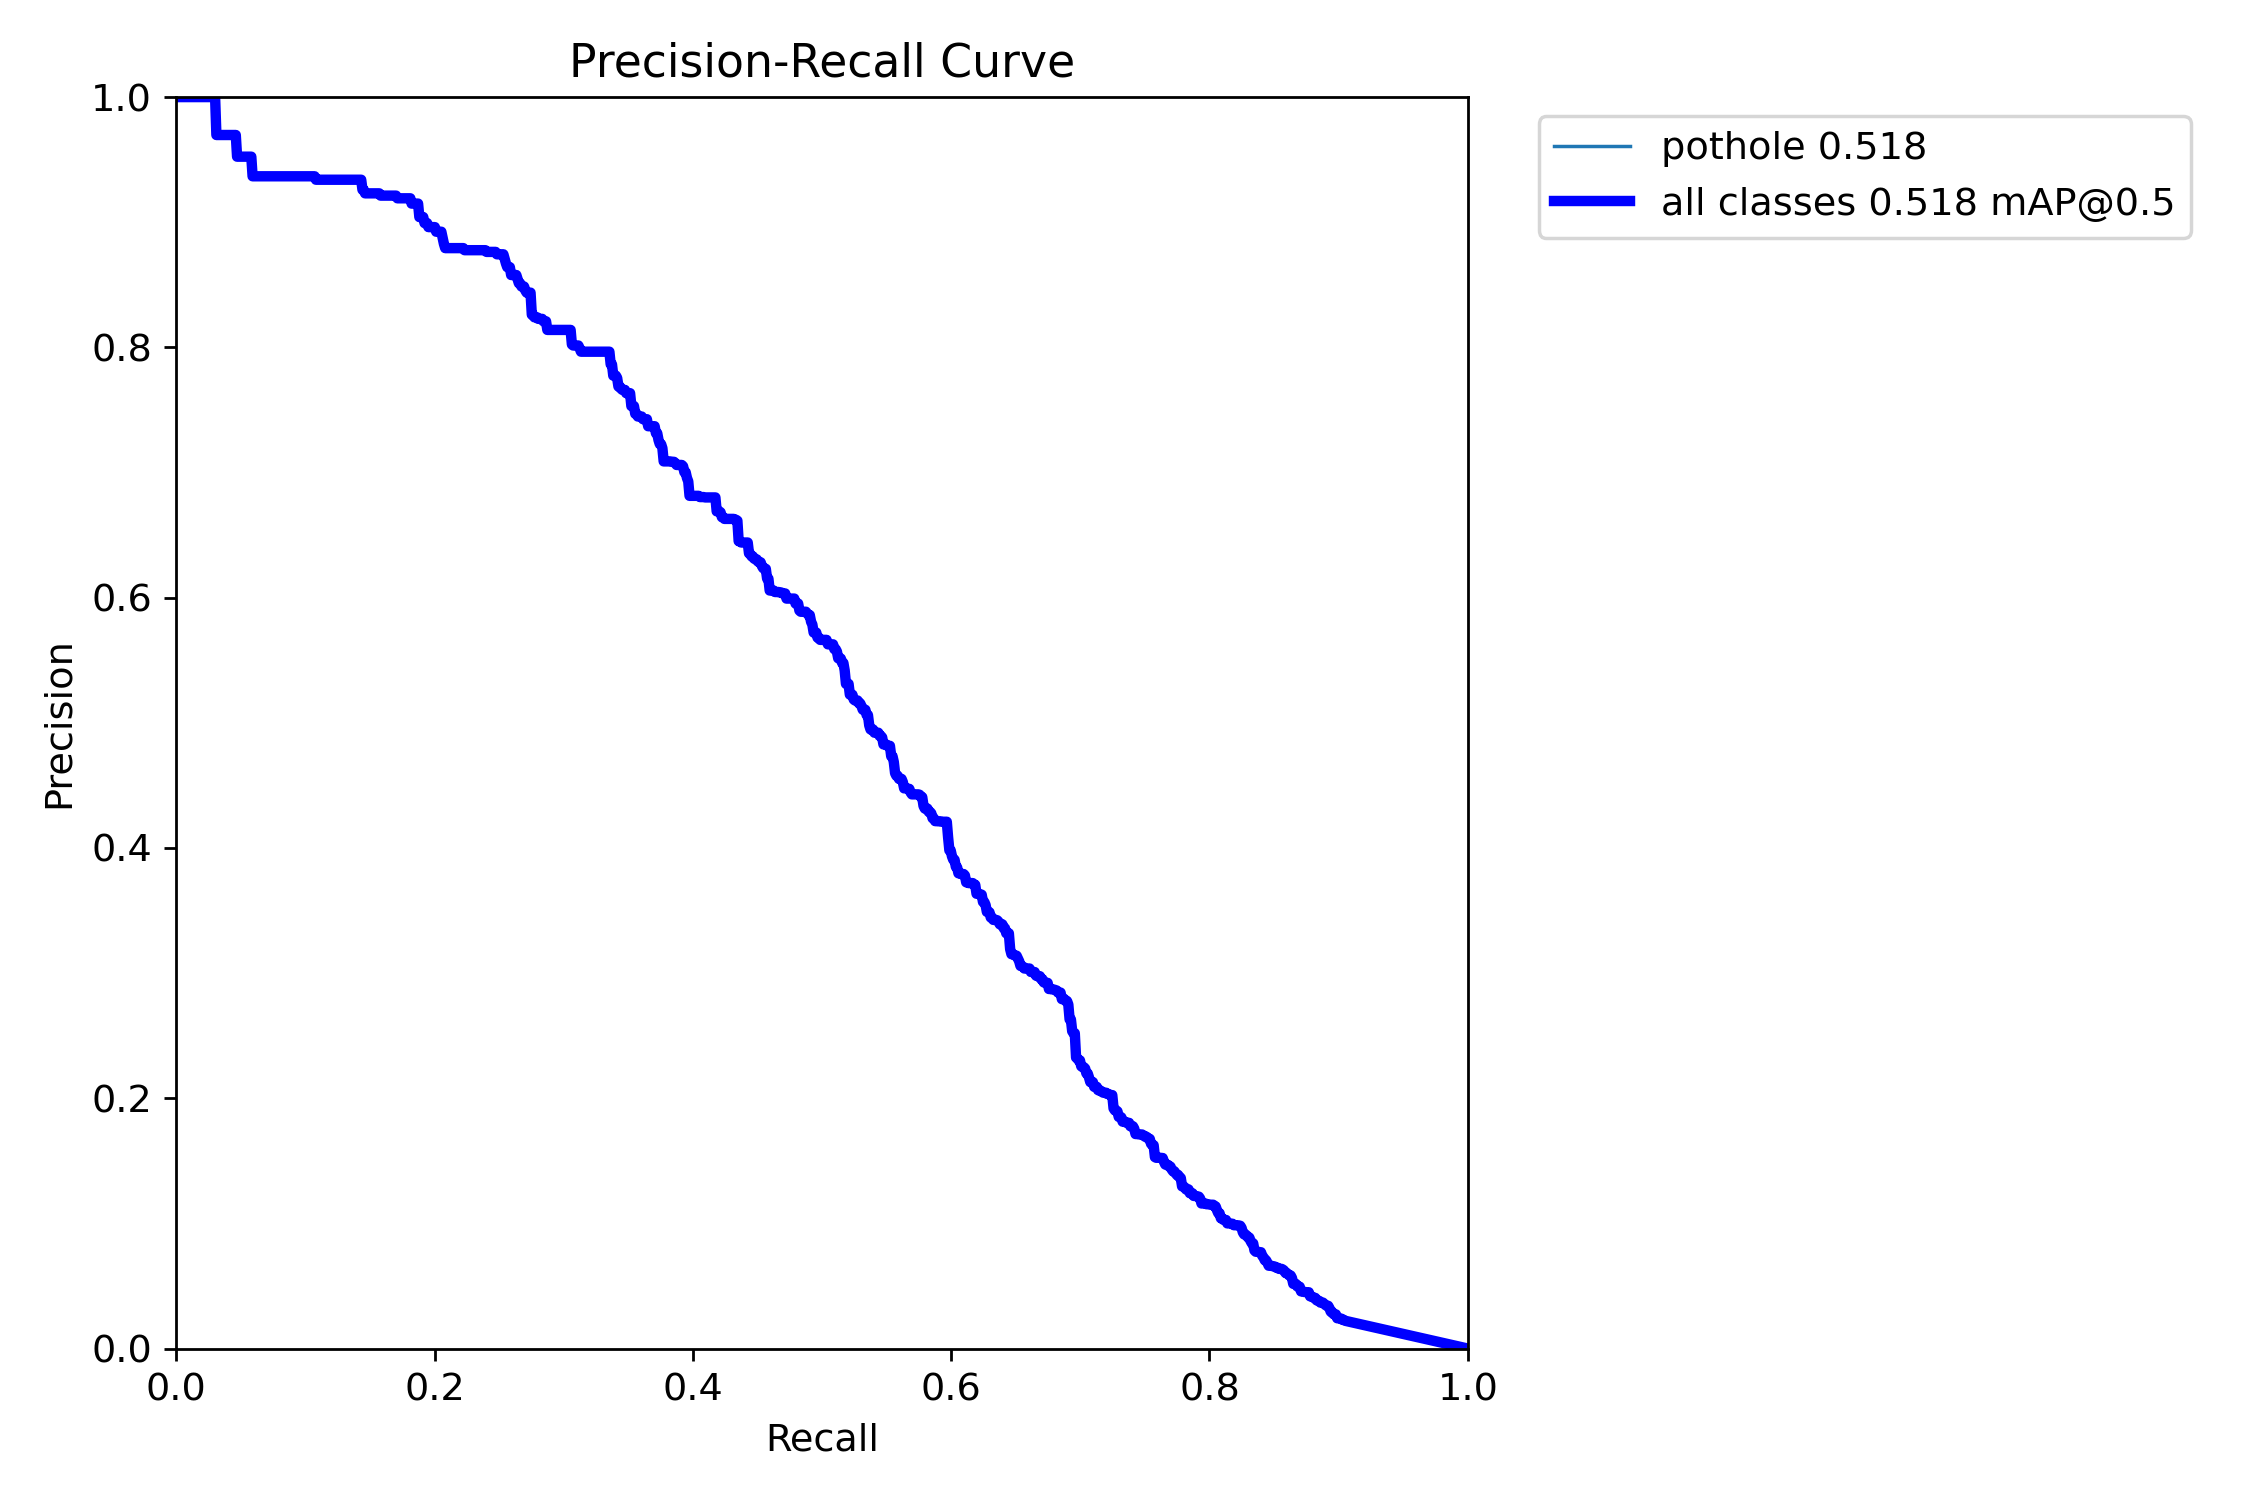


📊 F1 Score Curve


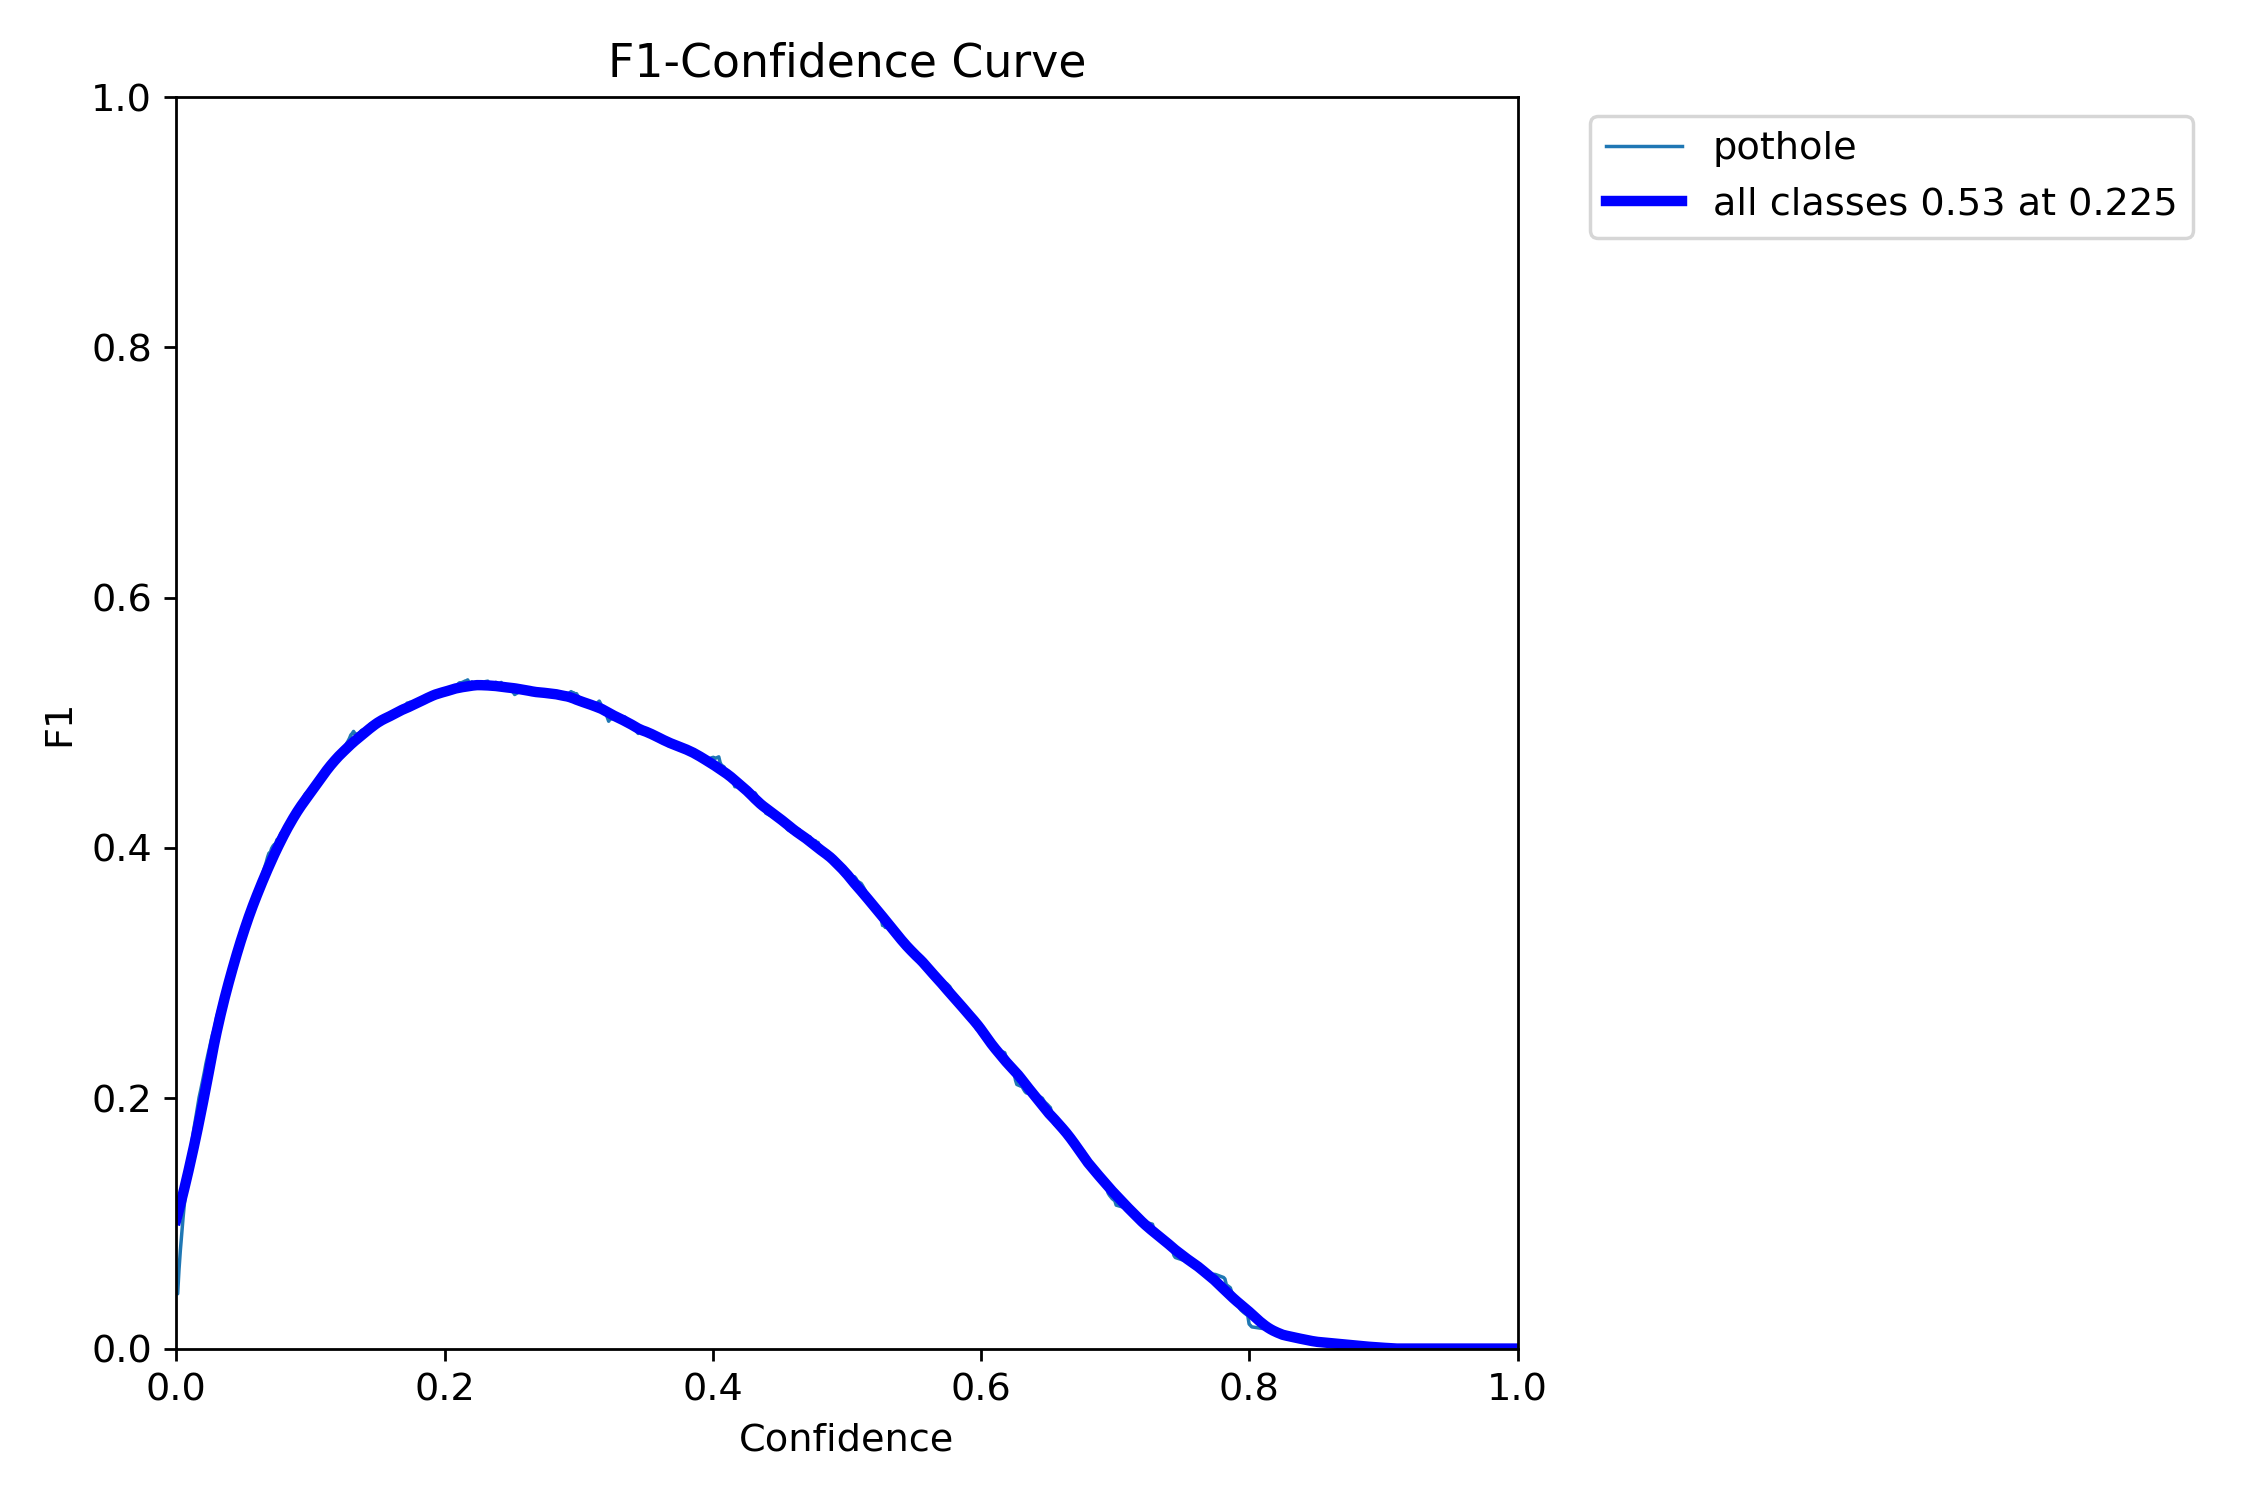

In [8]:
# ============================================================
# VIEW TRAINING CHARTS
# ============================================================
# These charts show how your model improved over 60 epochs.
# They are saved on your Drive from the completed training run.

from IPython.display import Image as IPyImage, display
import os

charts = {
    'results.png':          'Loss Curves + mAP over 60 Epochs',
    'confusion_matrix.png': 'Confusion Matrix',
    'val_batch0_pred.jpg':  'Sample Validation Predictions',
    'PR_curve.png':         'Precision-Recall Curve',
    'F1_curve.png':         'F1 Score Curve',
}

for filename, title in charts.items():
    fpath = f"{RUN_DIR}/{filename}"
    if os.path.exists(fpath):
        print(f"\n{'='*50}")
        print(f"📊 {title}")
        print('='*50)
        display(IPyImage(filename=fpath, width=700))
    else:
        print(f"⚠️  {filename} not found")

**Evaluate Results**

✅ Loading results from: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v1/


📊 Training Results: pothole_yolo11s_v1

──────────────────────────────────────────────────
Loss Curves + mAP
──────────────────────────────────────────────────


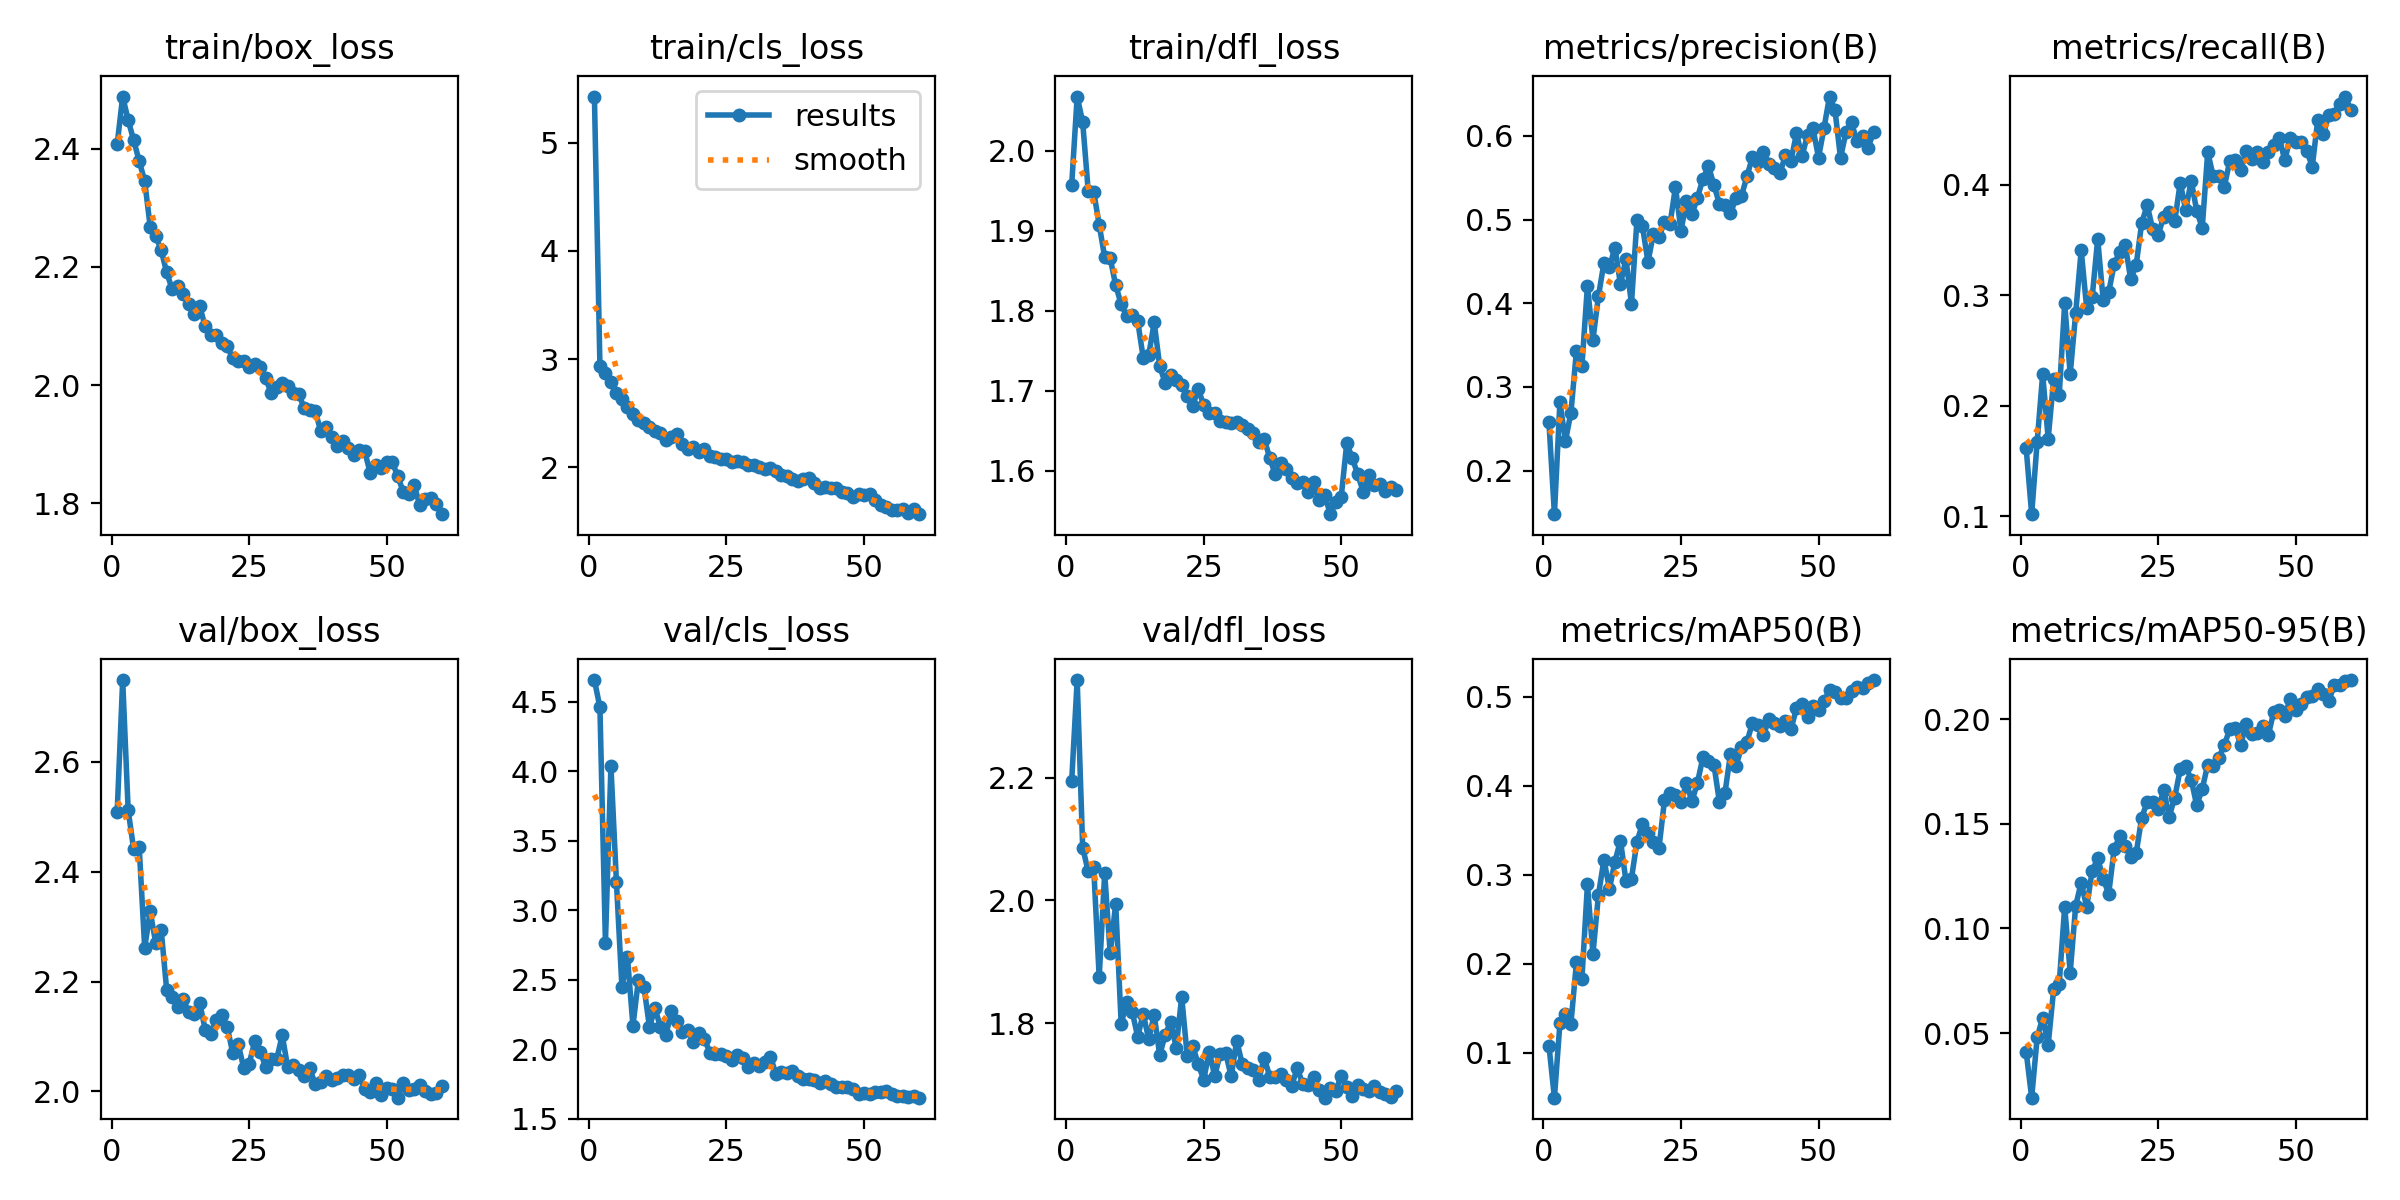


──────────────────────────────────────────────────
Confusion Matrix
──────────────────────────────────────────────────


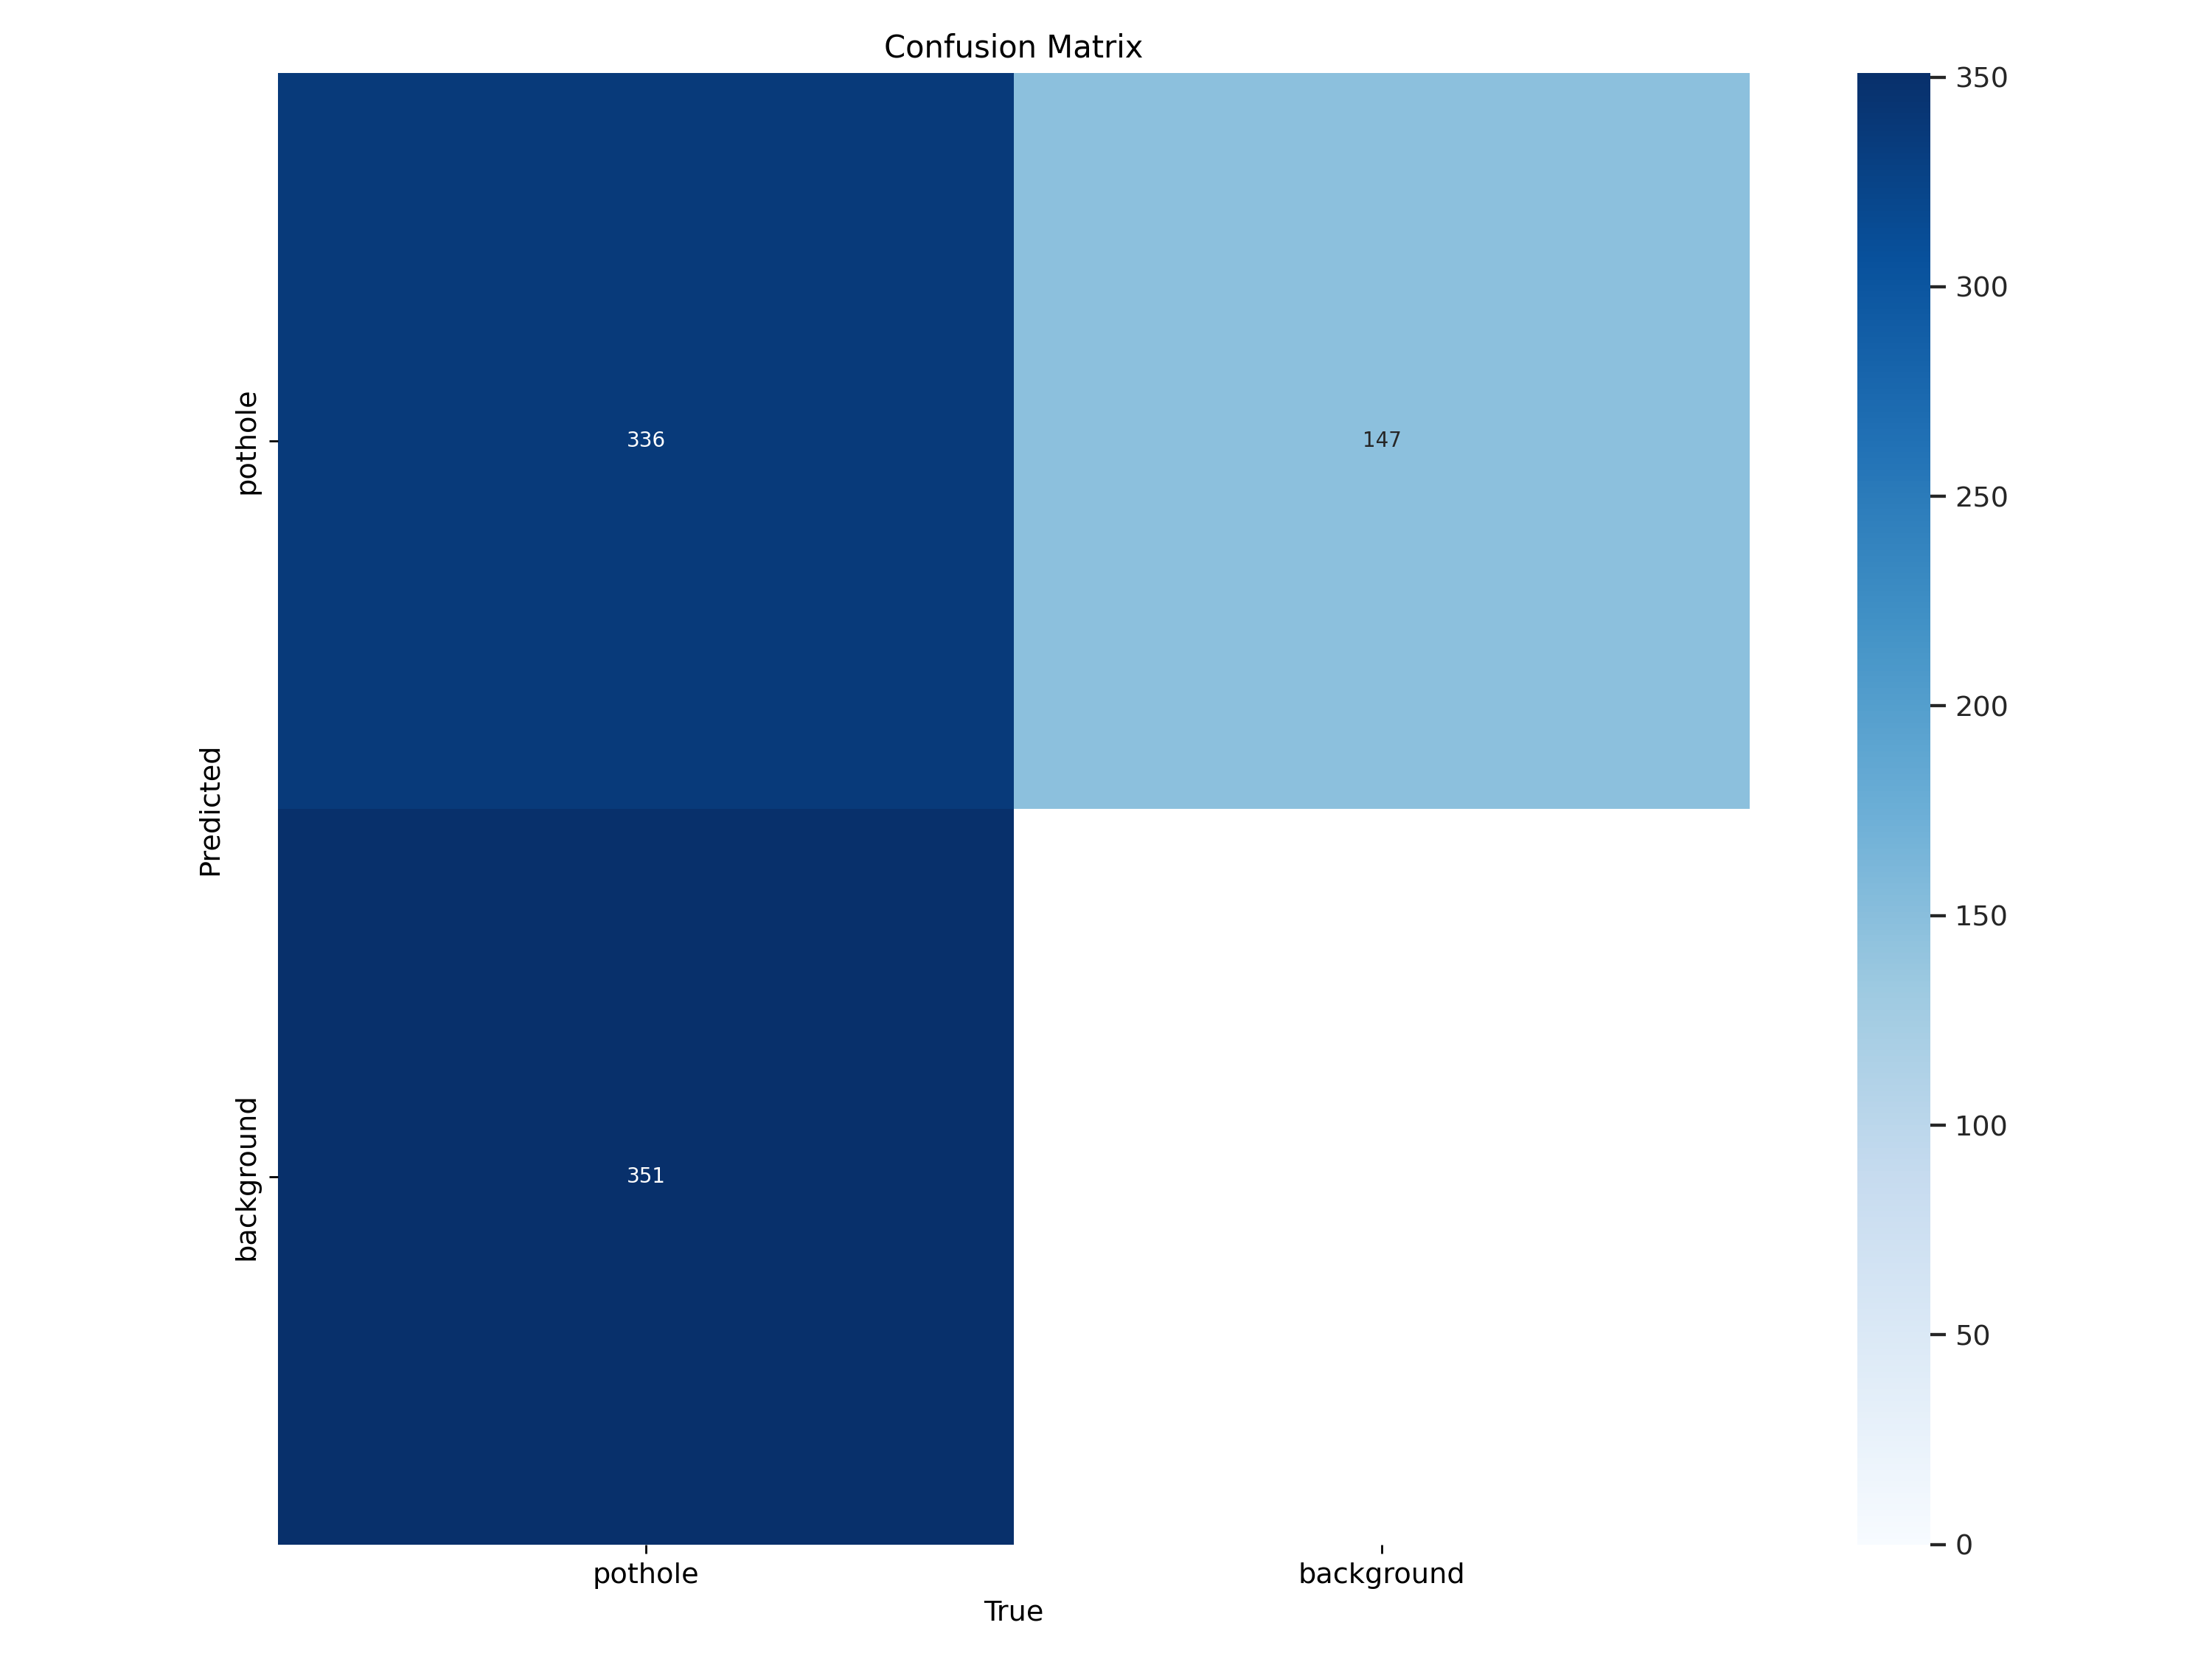


──────────────────────────────────────────────────
Confusion Matrix (Normalised)
──────────────────────────────────────────────────


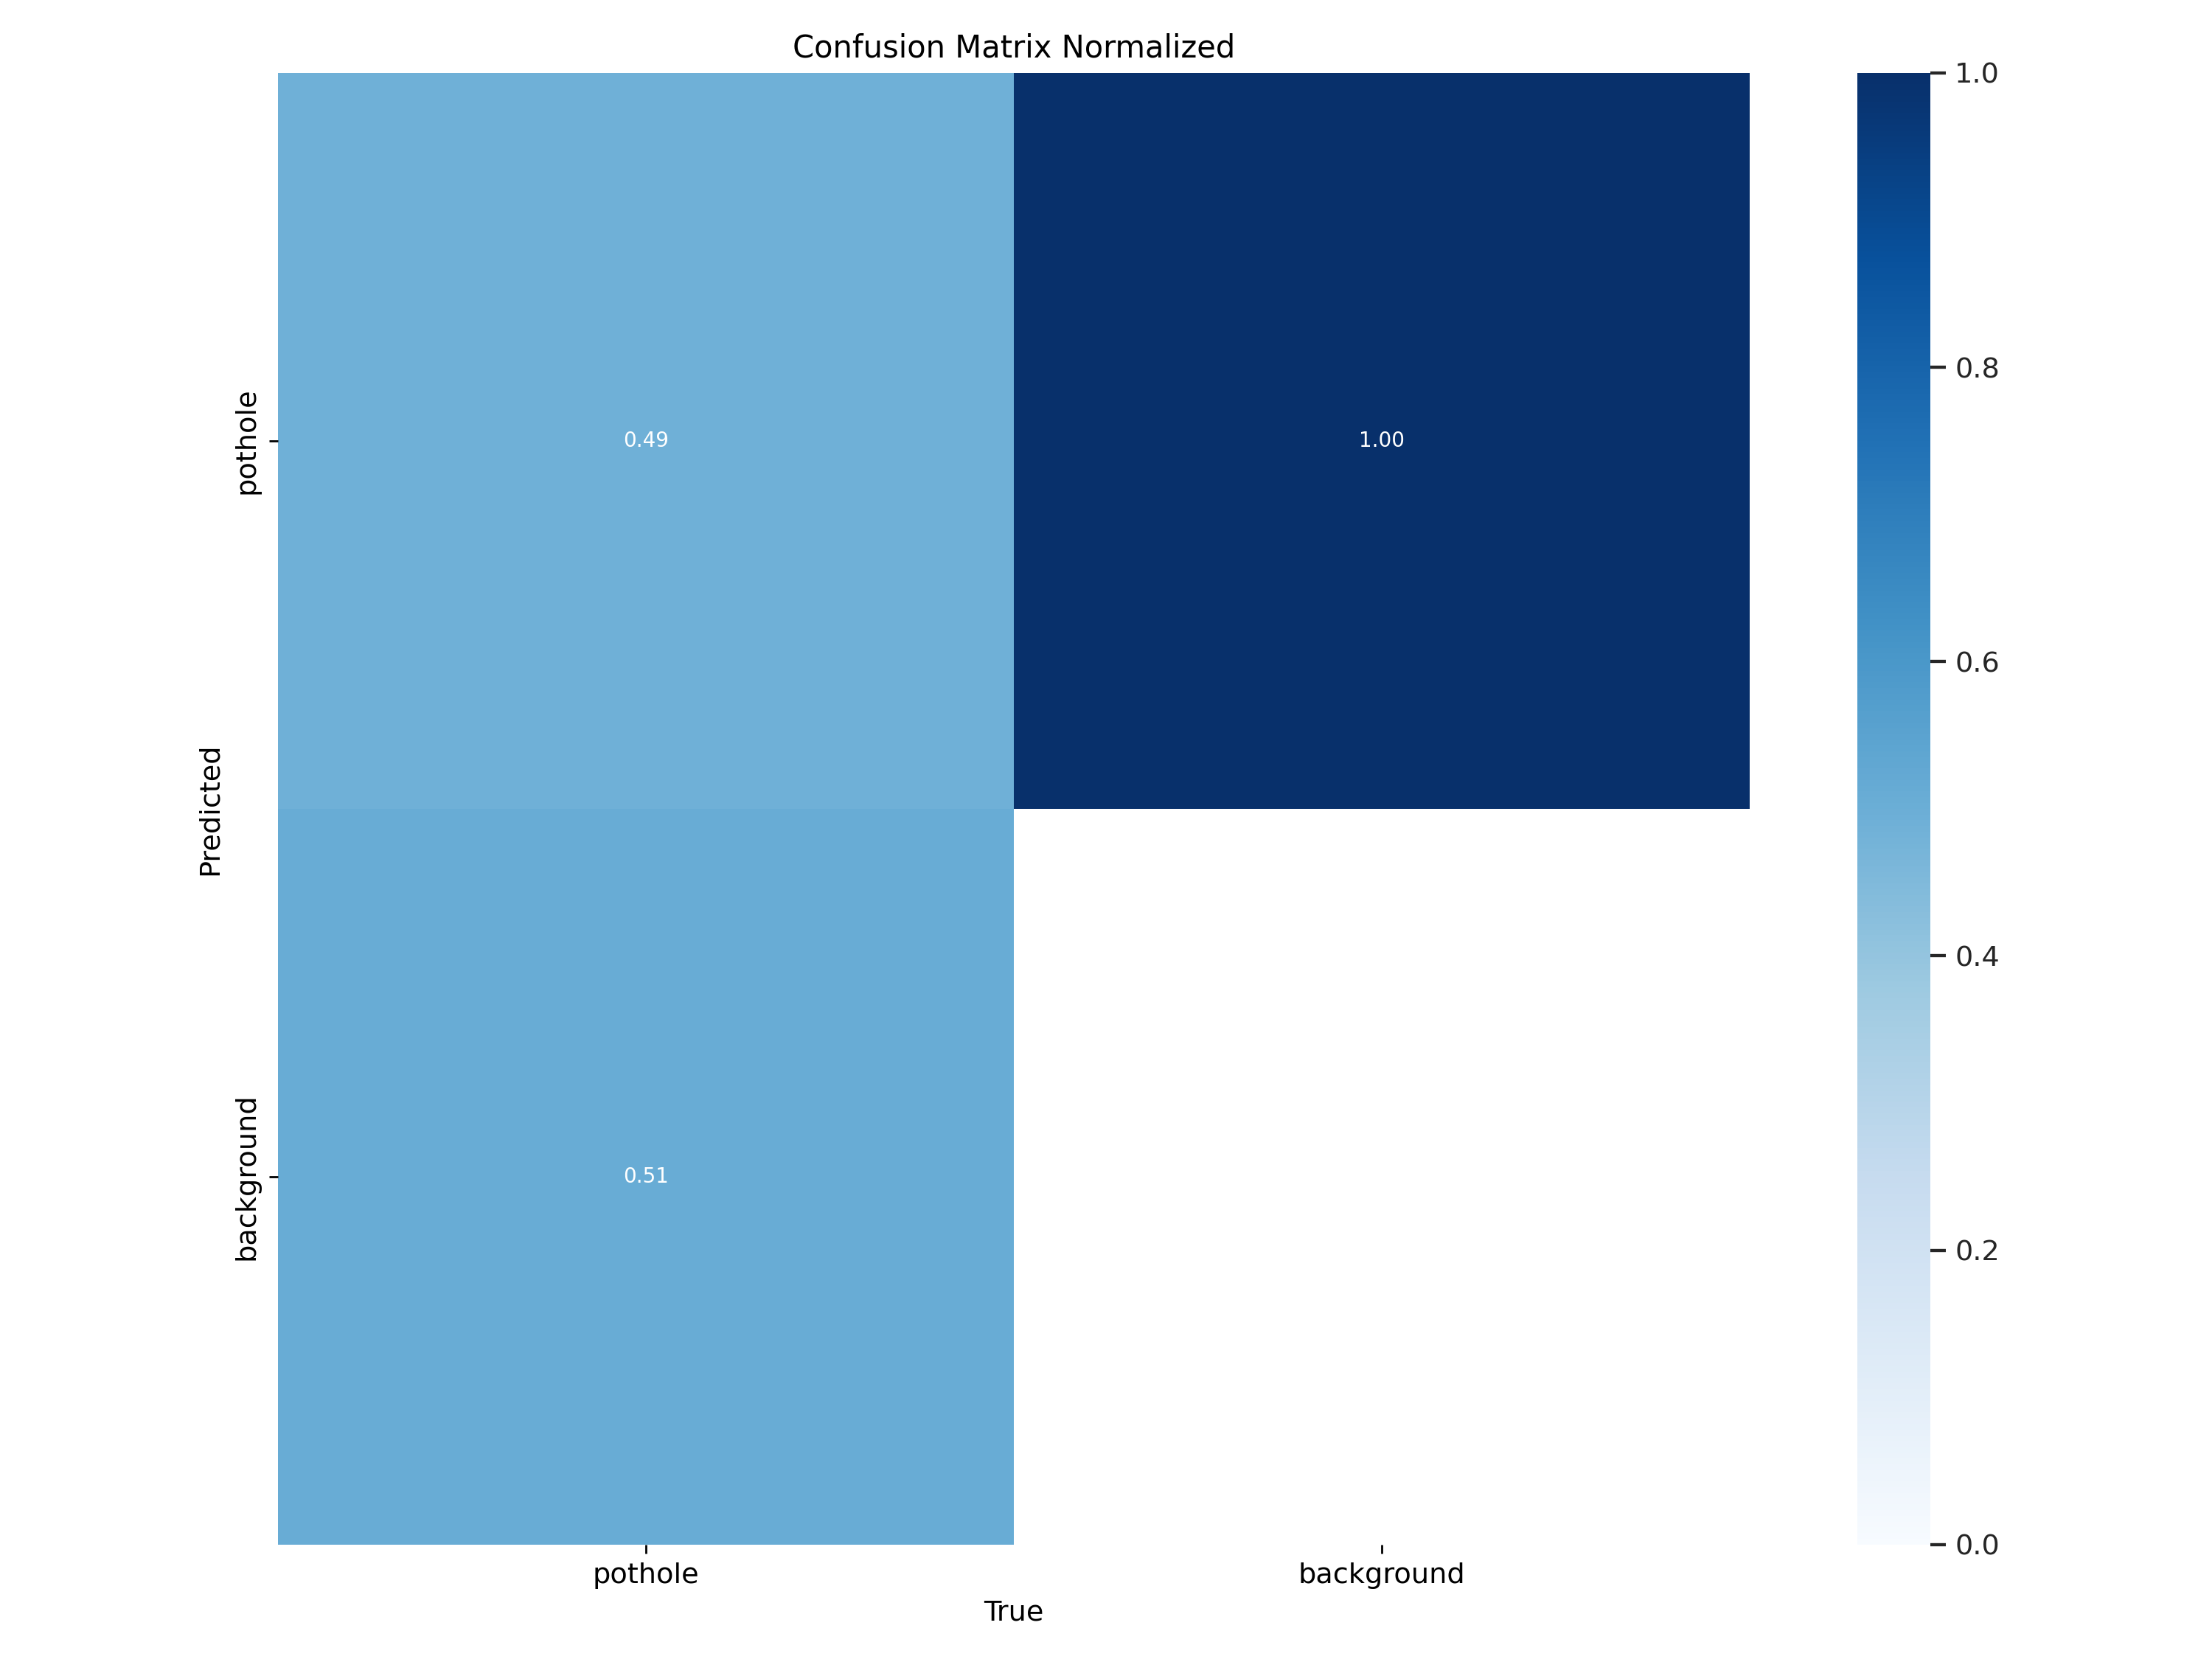


──────────────────────────────────────────────────
Sample Predictions (Batch 0)
──────────────────────────────────────────────────


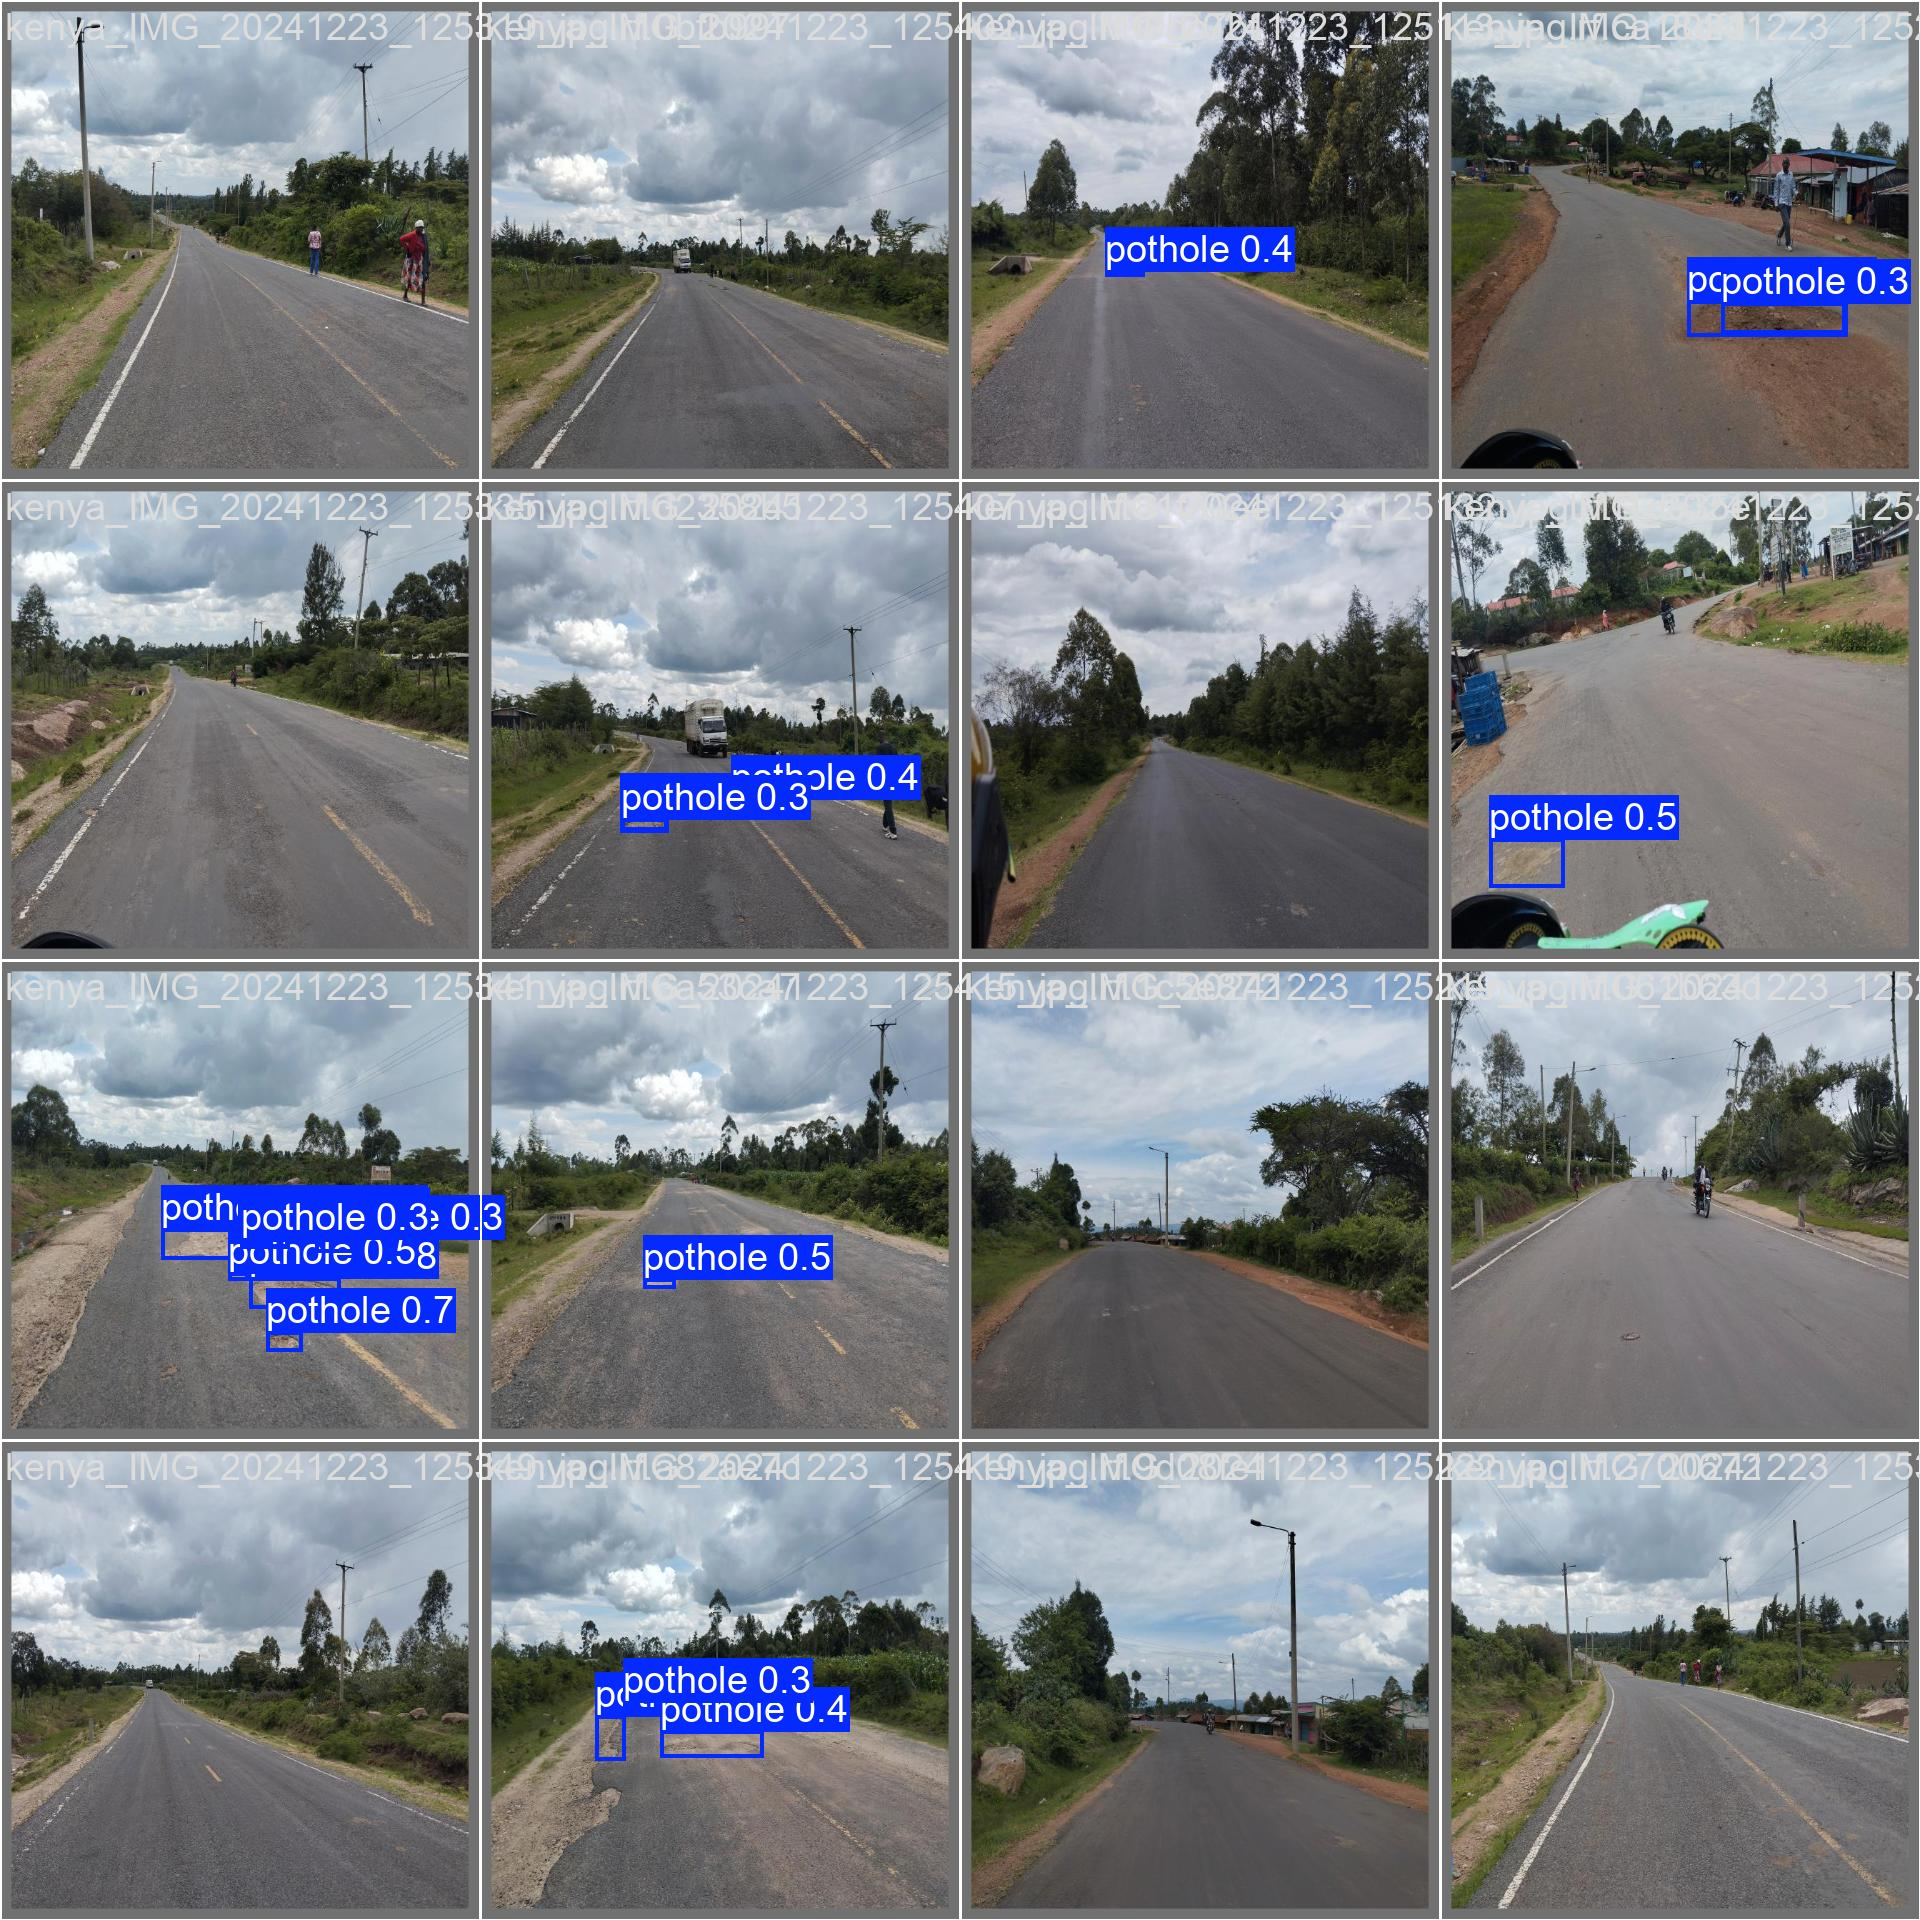


──────────────────────────────────────────────────
Sample Predictions (Batch 1)
──────────────────────────────────────────────────


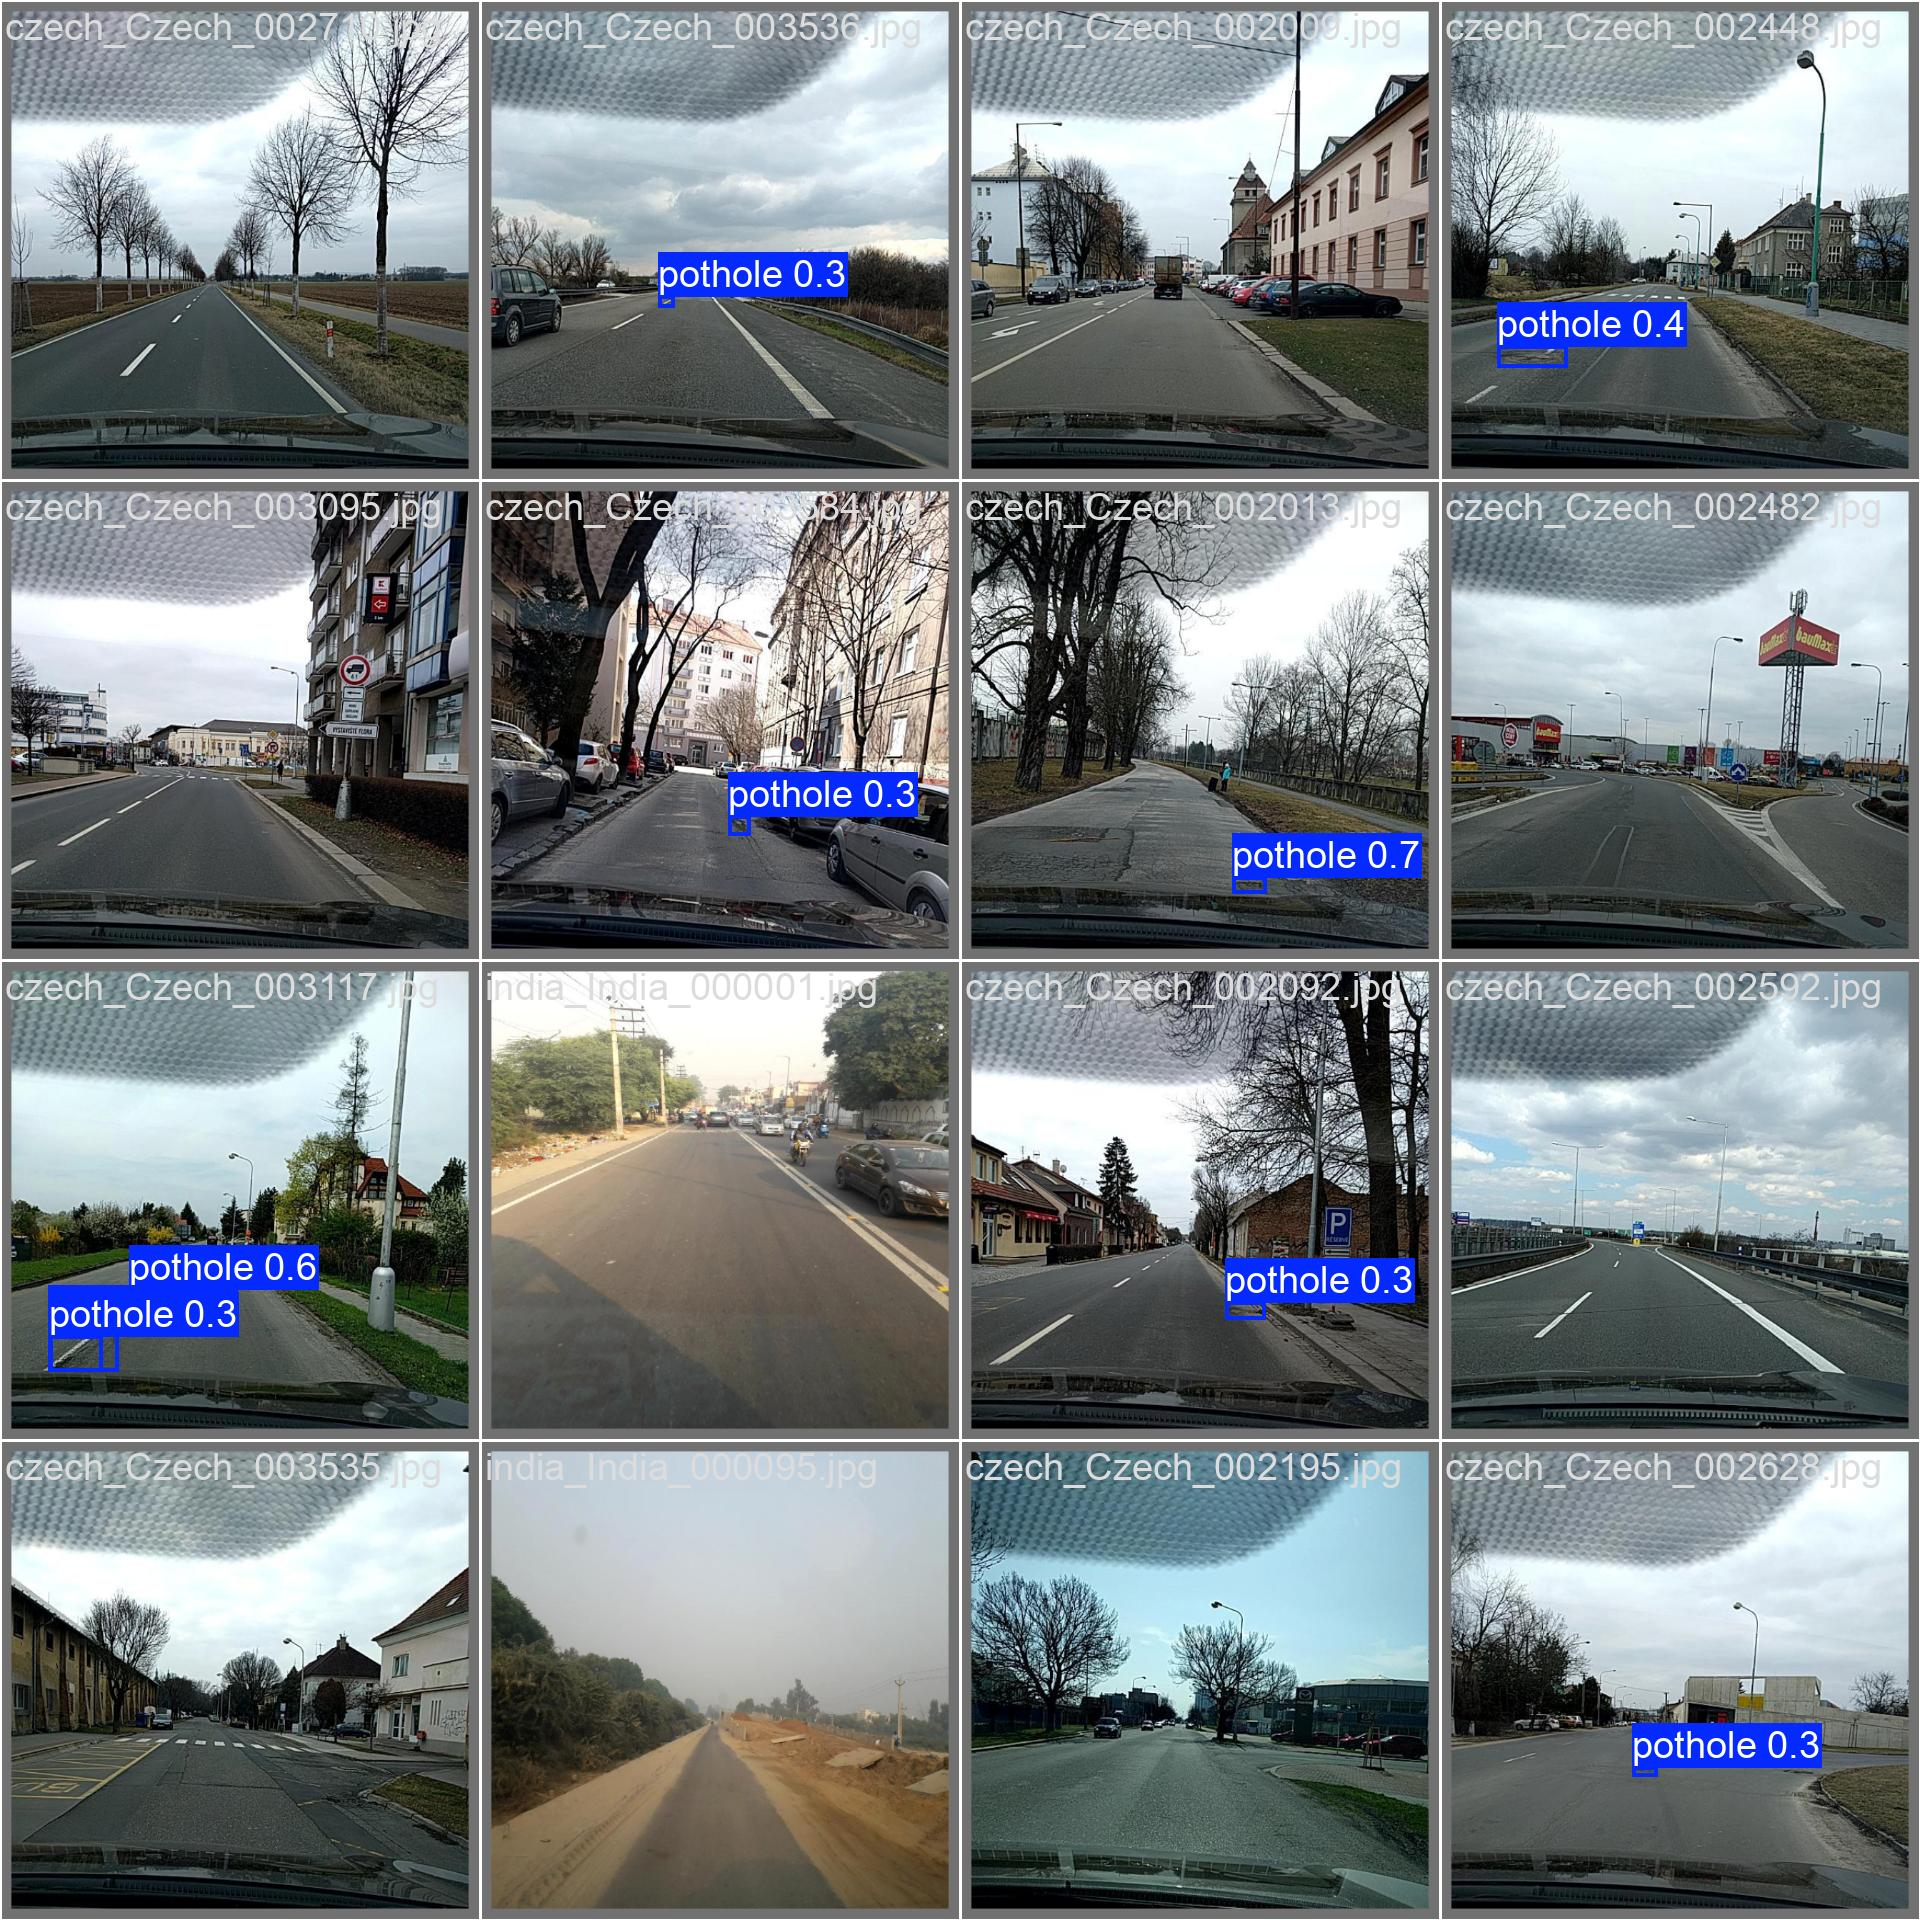


──────────────────────────────────────────────────
Precision-Recall Curve
──────────────────────────────────────────────────


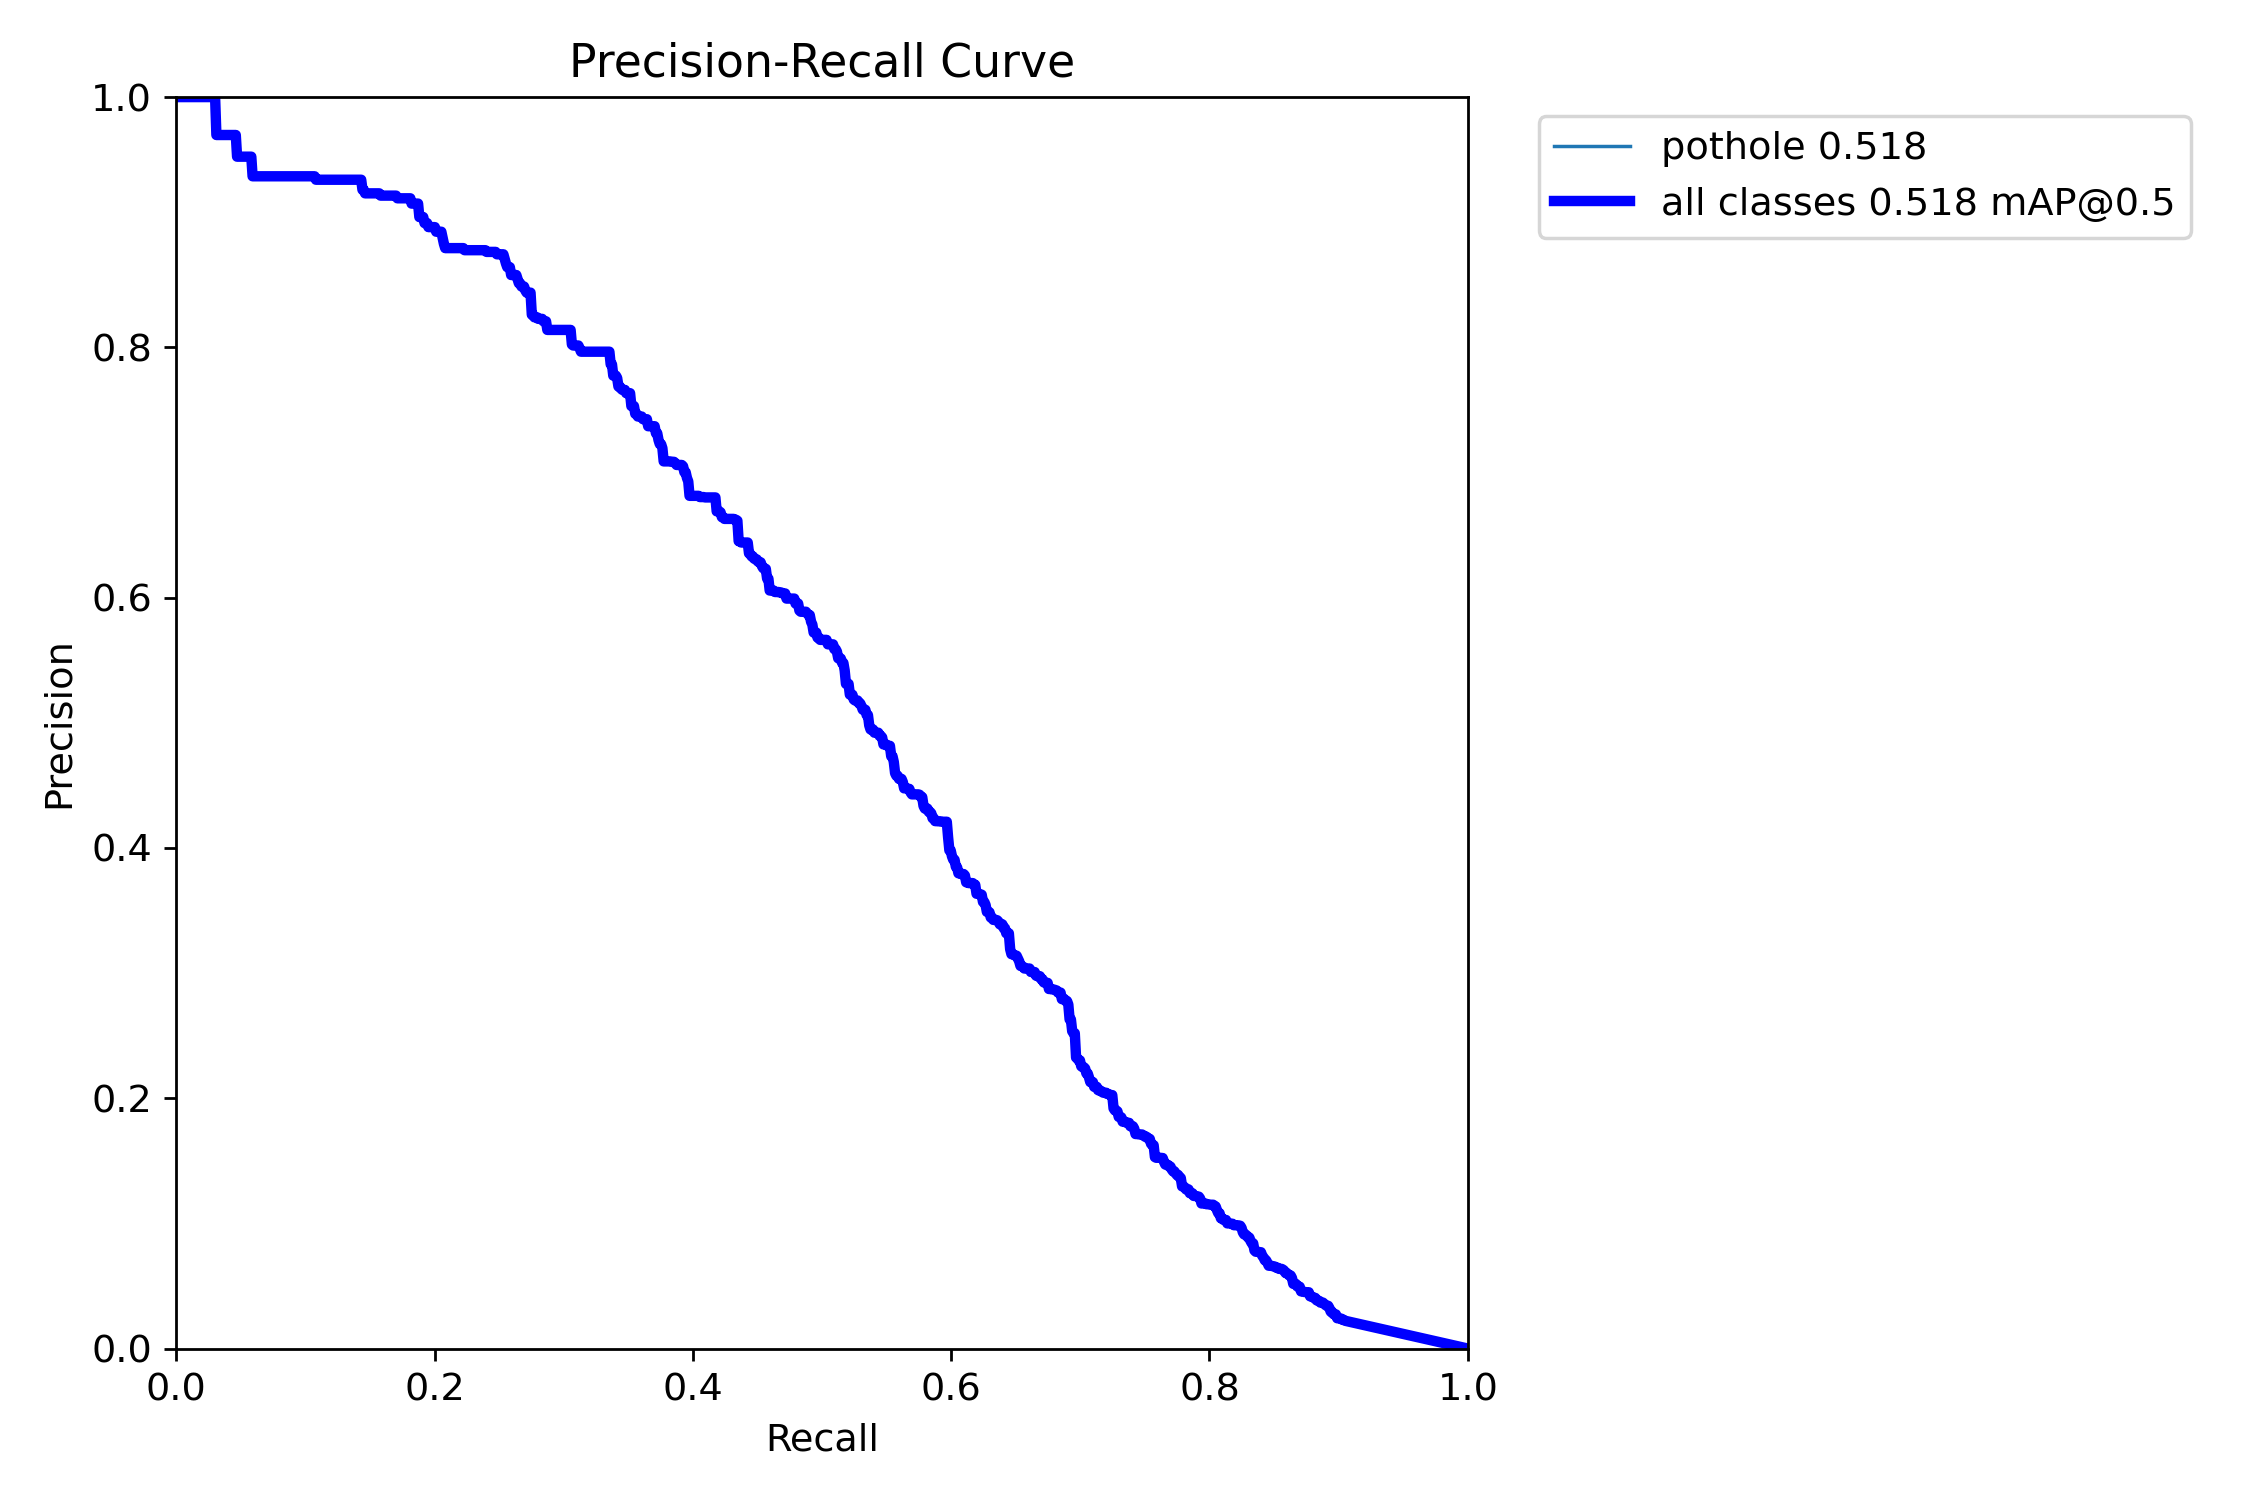


──────────────────────────────────────────────────
F1 Score Curve
──────────────────────────────────────────────────


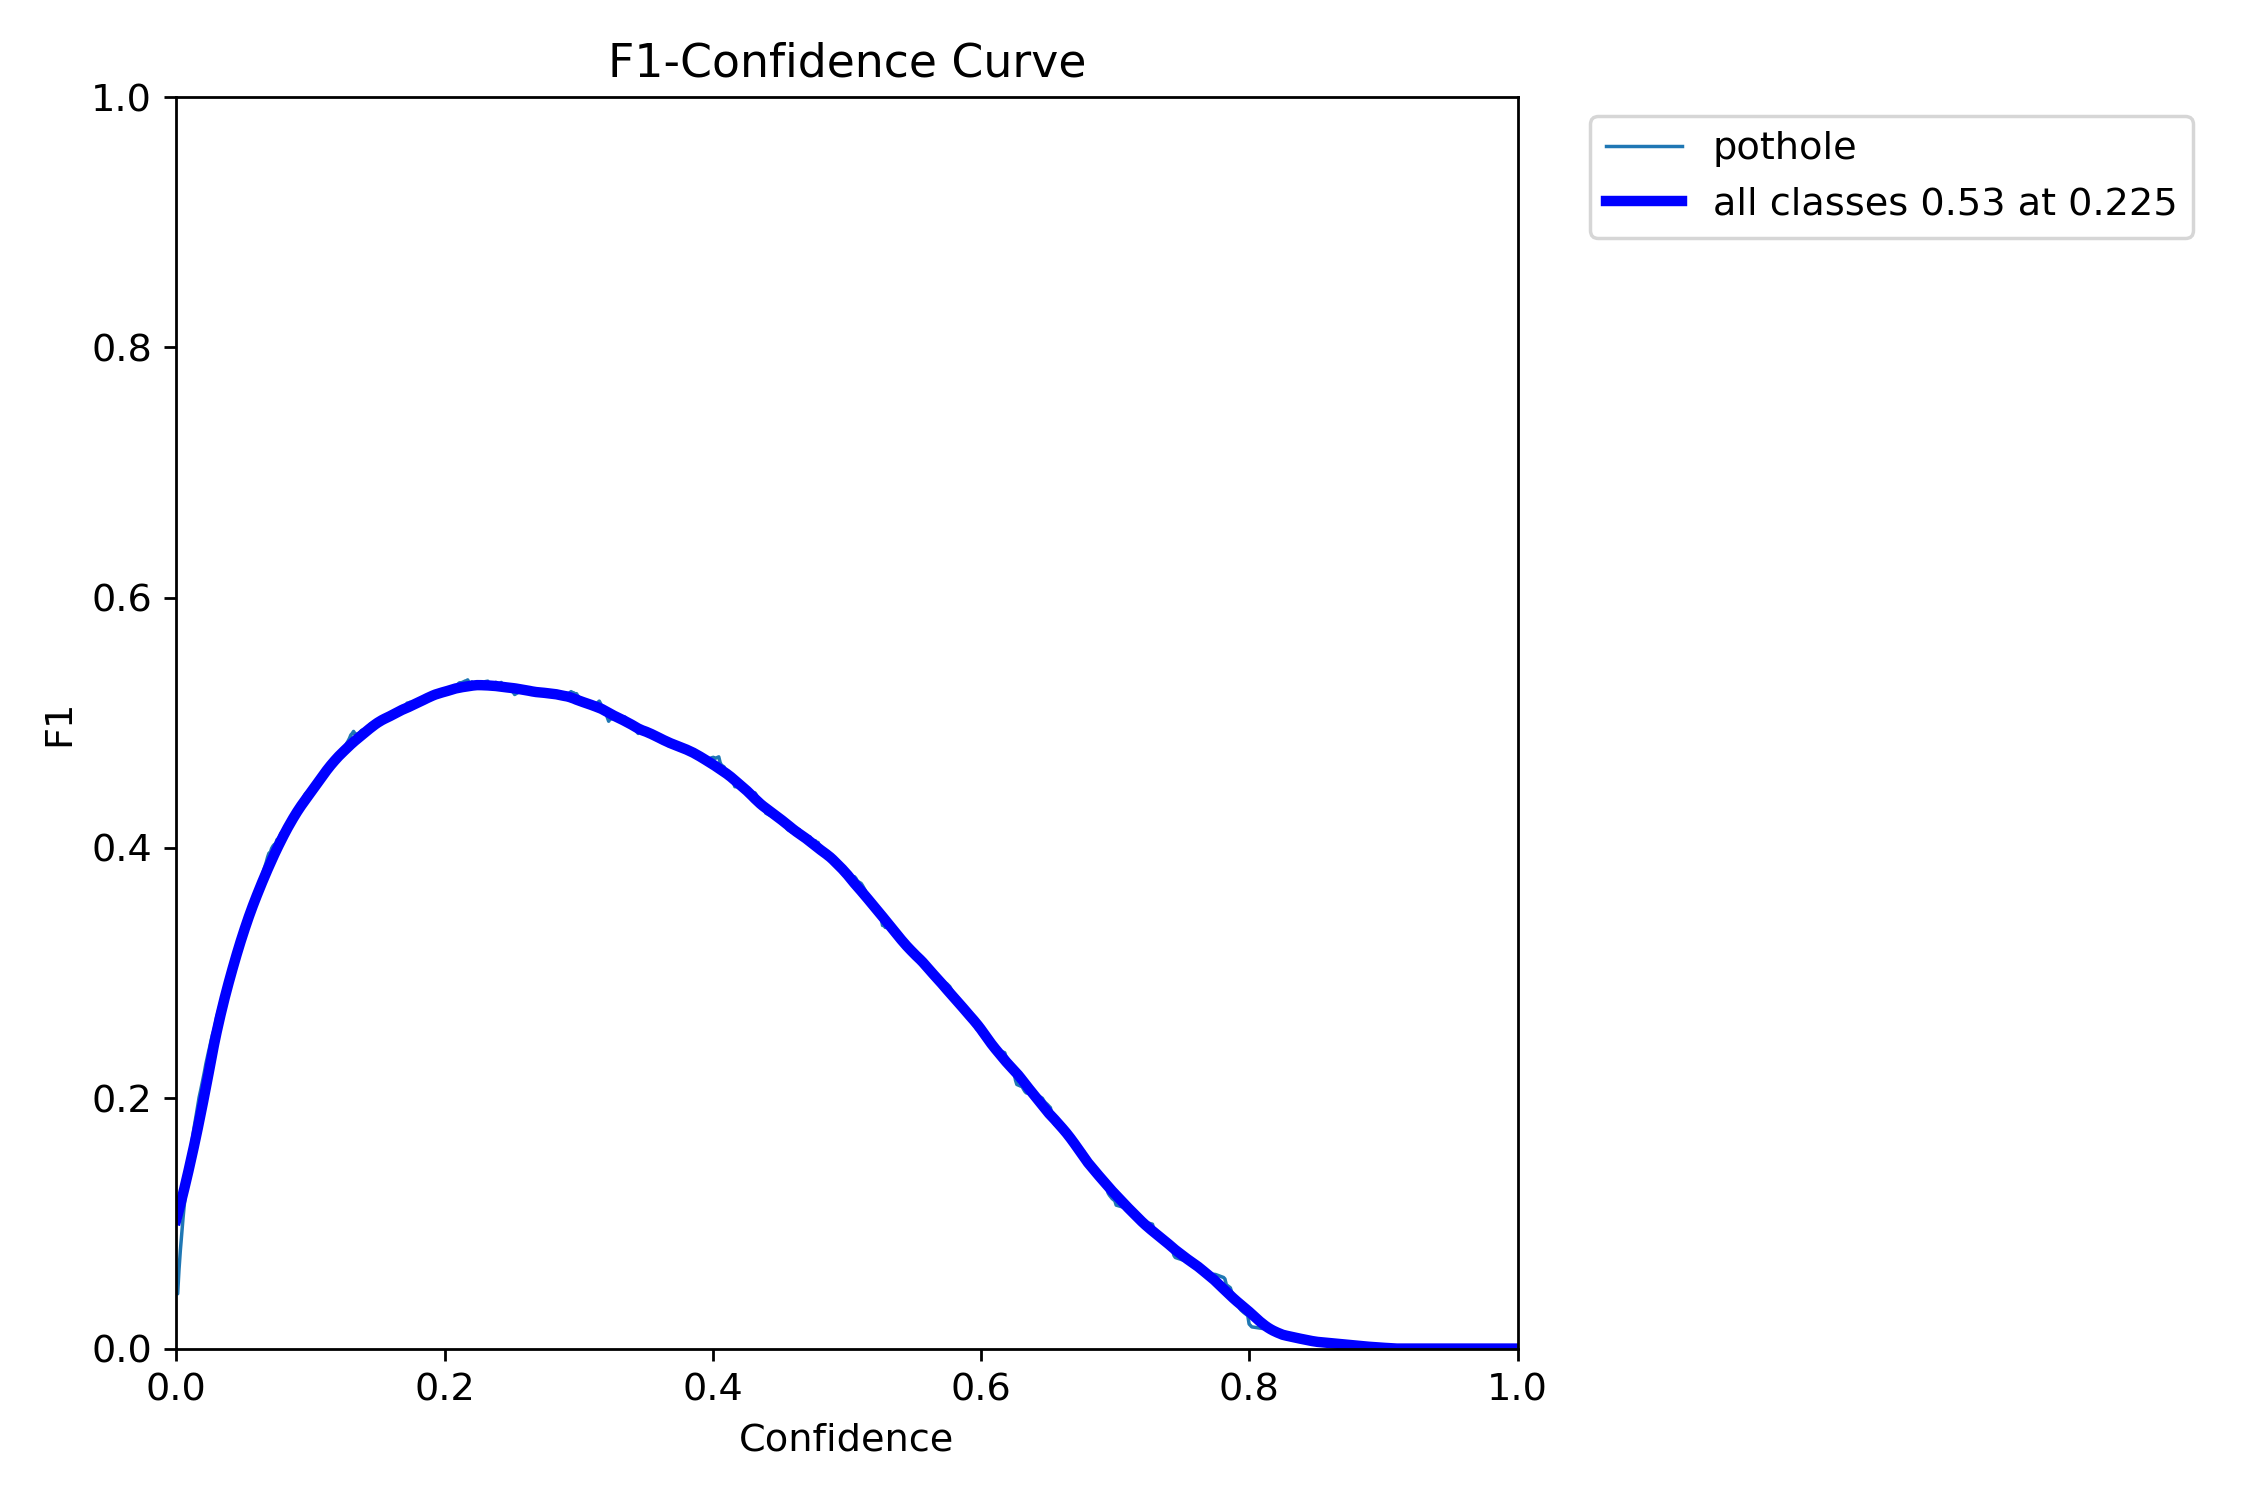


📊 Detailed training curves:


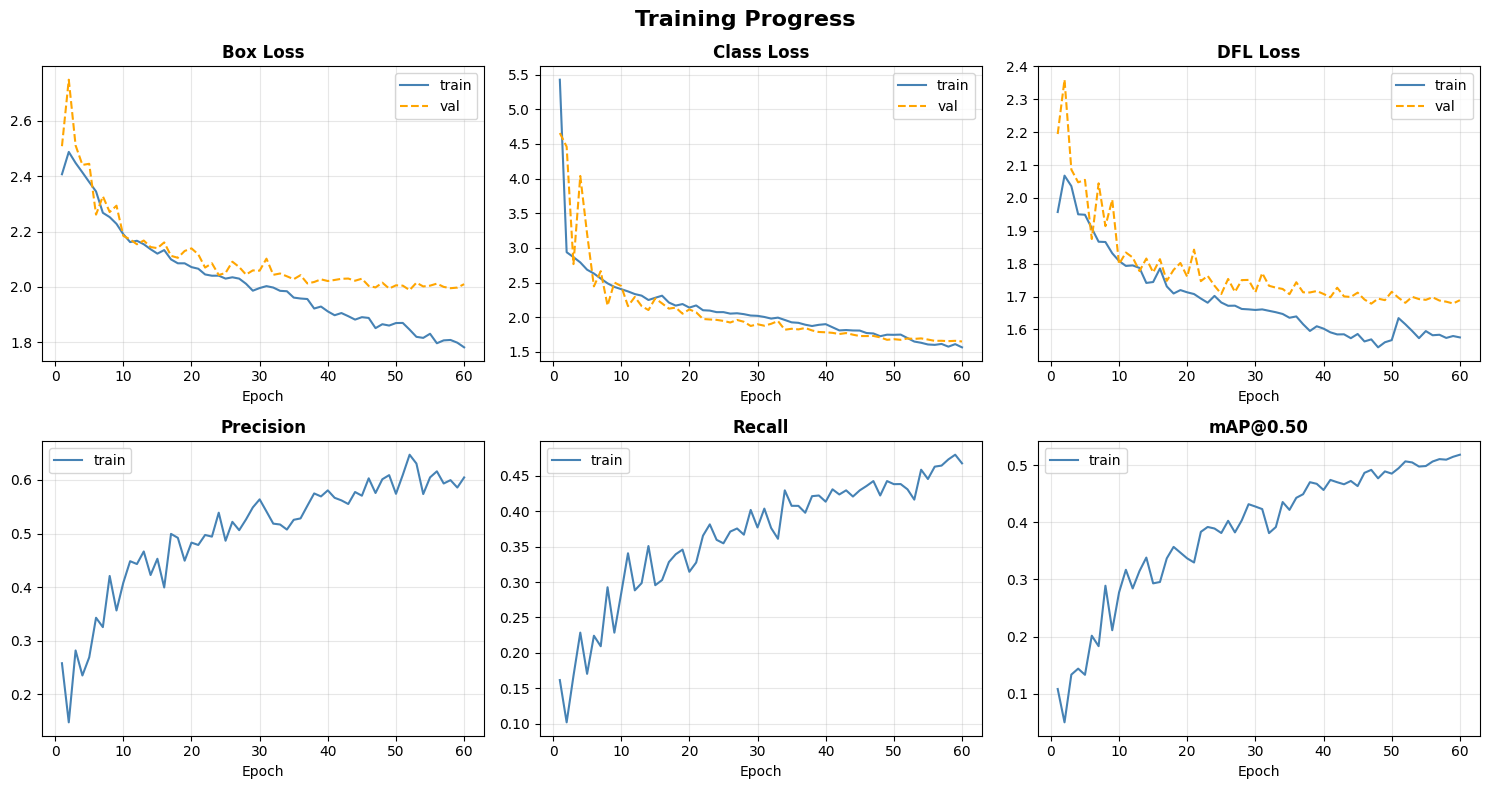

✅ Custom training curves plotted


In [10]:
# ============================================================
# SECTION 6: EVALUATE TRAINING RESULTS
# ============================================================
#
# After training, YOLO saves these files in the run folder:
#
#   results.png       → shows how loss and accuracy changed
#                       over every epoch. Loss should go DOWN.
#                       mAP should go UP.
#
#   confusion_matrix  → a grid showing what the model gets
#                       right and wrong. Diagonal = good.
#
#   val_batch_pred    → actual images with boxes drawn on them
#                       showing what the model predicted
#
# What is mAP50?
#   mAP50 = mean Average Precision at 50% overlap threshold.
#   A predicted box counts as correct if it overlaps the
#   real box by at least 50%.
#   Score ranges from 0.0 (useless) to 1.0 (perfect).
#   A score of 0.6+ is good for a first training run.
# ============================================================

import glob

RUN_NAME = "pothole_yolo11s_v1"

# Find the run folder (handles auto-numbering like _v12, _v13)
matching = glob.glob(f"{HOME}/runs/detect/{RUN_NAME}*/")
if not matching:
    # Try Drive backup
    matching = glob.glob(f"{DRIVE_RUNS}/{RUN_NAME}*/")

if not matching:
    print(f"❌ No training run found named '{RUN_NAME}'")
    print("   Make sure Section 4 completed successfully.")
else:
    RUN_DIR = max(matching, key=os.path.getmtime)
    print(f"✅ Loading results from: {RUN_DIR}\n")
    plot_training_results(RUN_DIR)

    # Also plot custom CSV curves
    csv_path = os.path.join(RUN_DIR, 'results.csv')
    if os.path.exists(csv_path):
        print("\n📊 Detailed training curves:")
        plot_training_csv(csv_path)

**Validate on Test Set**

In [11]:
# ============================================================
# SECTION 6B: VALIDATE ON TEST SET
# ============================================================
#
# The test set contains images the model has NEVER seen.
# Not during training. Not during validation.
# This gives us the most honest accuracy number.
#
# The key number to look for: mAP50
# A model with mAP50 = 0.65 means: when the model draws a box
# around something it thinks is a pothole, it is right 65%
# of the time AND it finds 65% of the potholes in the image.
# ============================================================

DATA_YAML = f"{COMBINED_DIR}/data.yaml"
BEST_PT   = os.path.join(RUN_DIR, 'weights', 'best.pt')

if not os.path.exists(BEST_PT):
    print(f"❌ No trained weights at: {BEST_PT}")
    print("   Run Section 4 or Section 5 first.")
else:
    print(f"✅ Evaluating: {BEST_PT}\n")

    !yolo task=detect mode=val \
          model={BEST_PT} \
          data={DATA_YAML} \
          plots=True

    print("\n✅ Validation complete.")
    print("   Look for 'mAP50' in the table above.")
    print("   0.5+ = good  |  0.7+ = very good  |  0.85+ = excellent")

✅ Evaluating: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v1/weights/best.pt

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 972, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 638, in val
    validator(model=self.model)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/validator.py", line 145, in __call__
   

 **Run on New Images**

🔍 Running pothole detection on test images...
   Model: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v1/weights/best.pt
   Images: /content/datasets/combined/test/images

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/642 /content/datasets/combined/test/images/czech_Czech_000240.jpg: 640x640 (no detections), 870.6ms
image 2/642 /content/datasets/combined/test/images/czech_Czech_000293.jpg: 640x640 3 potholes, 710.2ms
image 3/642 /content/datasets/combined/test/images/czech_Czech_000384.jpg: 640x640 (no detections), 524.8ms
image 4/642 /content/datasets/combined/test/images/czech_Czech_000395.jpg: 640x640 (no detections), 514.2ms
image 5/642 /content/datasets/combined/test/images/czech_Czech_000458.jpg: 640x640 (no detections), 527.3ms
image 6/642 /content/datasets/combined/test/images/czech_Czech_000499.jpg: 640x640 (no detections), 510.4ms
image 7/642 /c

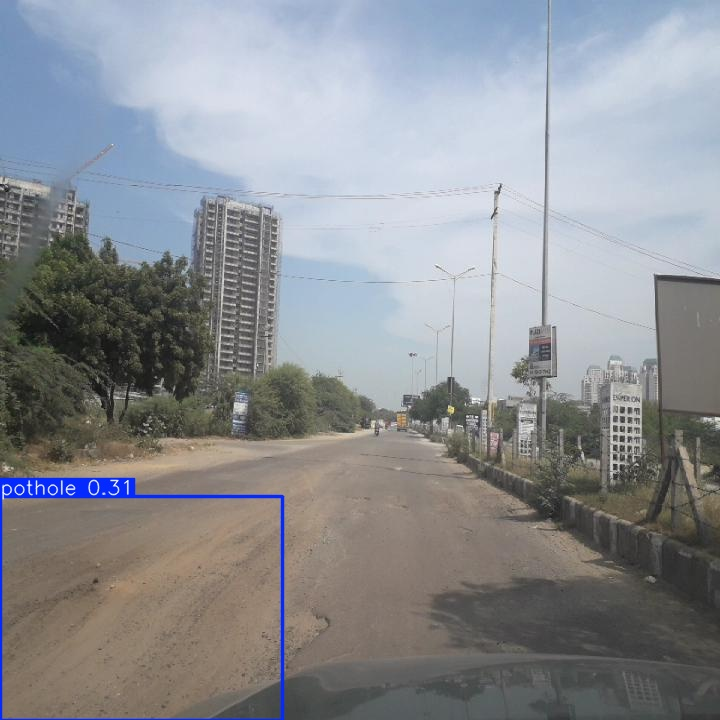


  india_India_004902.jpg


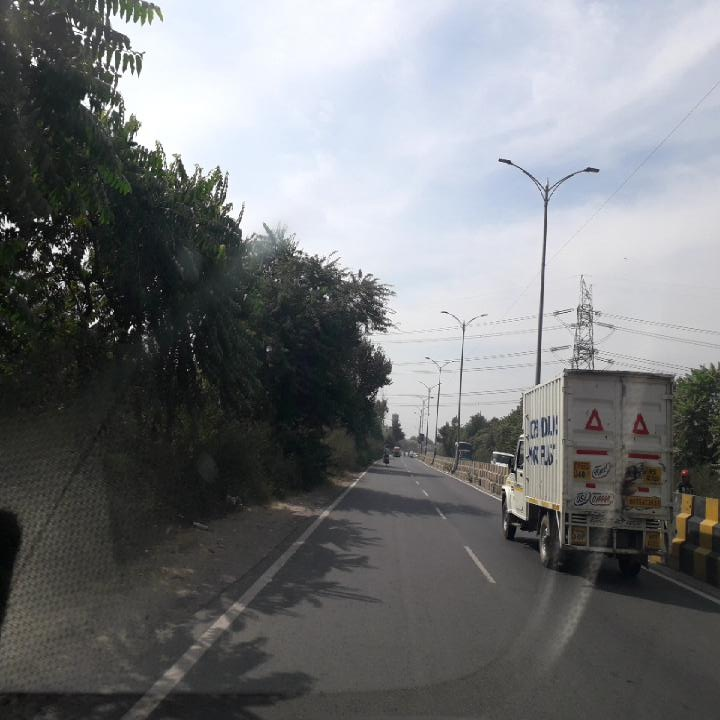


  india_India_008029.jpg


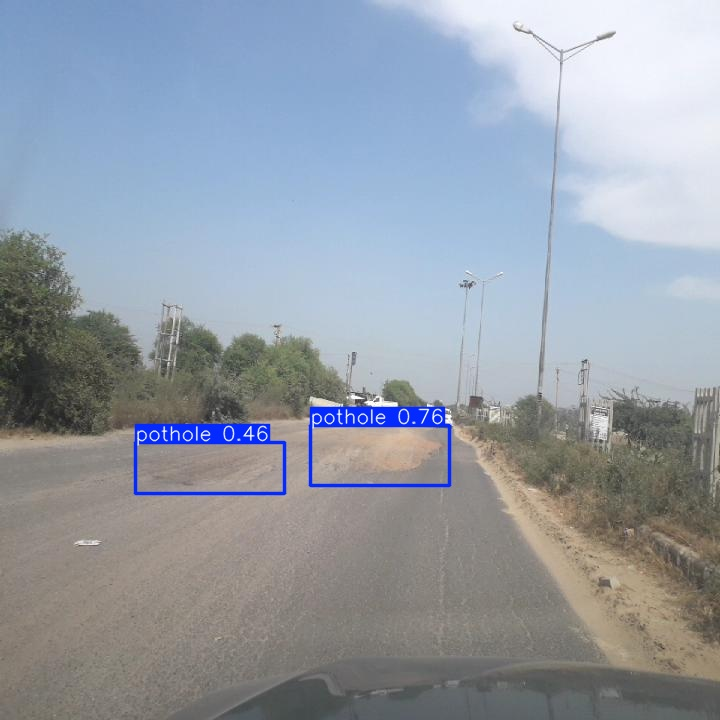


  india_India_006523.jpg


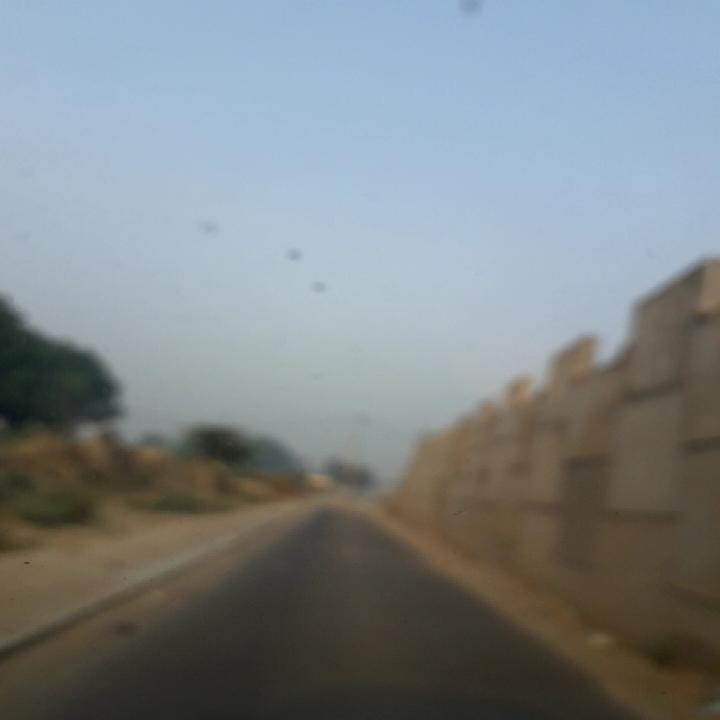

In [31]:
# ============================================================
# SECTION 7: RUN THE MODEL ON NEW ROAD IMAGES
# ============================================================
#
# This is the most exciting part.
# We take images from the test set (ones the model never saw)
# and ask the model to find potholes in them.
#
# The model draws a bounding box around each pothole it finds.
# Next to each box it shows a confidence score (0.0 to 1.0).
# For example: "pothole 0.87" means the model is 87% confident
# that what it found is a pothole.
#
# conf=0.25 means: only show detections the model is at
# least 25% confident about. Lower = shows more (including
# wrong ones). Higher = shows fewer (only very confident ones).
# ============================================================

DATA_YAML  = f"{COMBINED_DIR}/data.yaml"
BEST_PT    = os.path.join(RUN_DIR, 'weights', 'best.pt')
TEST_IMGS  = f"{COMBINED_DIR}/test/images"

import yaml
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
test_path = cfg.get('test', TEST_IMGS)

if not os.path.exists(BEST_PT):
    print("❌ No trained model found. Run Section 4 first.")
elif not os.path.exists(test_path):
    print(f"❌ Test images not found at: {test_path}")
else:
    os.chdir(HOME)
    print(f"🔍 Running pothole detection on test images...")
    print(f"   Model: {BEST_PT}")
    print(f"   Images: {test_path}\n")

    !yolo task=detect mode=predict \
          model={BEST_PT} \
          conf=0.25 \
          source={test_path} \
          save=True \
          name=pothole_predictions

    # Display random sample of predictions
    pred_dirs = glob.glob(f'{HOME}/runs/detect/pothole_predictions*/')
    if pred_dirs:
        latest = max(pred_dirs, key=os.path.getmtime)
        show_random_predictions(latest, n=4)
    else:
        print("❌ No prediction output found")

In [13]:
# ============================================================
# CREATE / LOCATE FOLDER FOR YOUR OWN TEST PHOTOS
# ============================================================
MY_TEST_DIR = f"{DRIVE_ROOT}/my_test_images"
os.makedirs(MY_TEST_DIR, exist_ok=True)
print(f"✅ Upload your photos here in Google Drive:")
print(f"   {MY_TEST_DIR}")
print(f"   (In Drive: My Drive → PotholeAI → my_test_images)")

✅ Upload your photos here in Google Drive:
   /content/drive/MyDrive/PotholeAI/my_test_images
   (In Drive: My Drive → PotholeAI → my_test_images)


Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/4 /content/drive/MyDrive/PotholeAI/my_test_images/iStock-655985038.jpg: 384x800 3 potholes, 517.9ms
image 2/4 /content/drive/MyDrive/PotholeAI/my_test_images/images (2).jpg: 512x800 2 potholes, 674.7ms
image 3/4 /content/drive/MyDrive/PotholeAI/my_test_images/images (3).jpg: 320x800 4 potholes, 357.6ms
image 4/4 /content/drive/MyDrive/PotholeAI/my_test_images/pothole.jpeg: 544x800 2 potholes, 631.2ms
Speed: 5.0ms preprocess, 545.3ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 800)
Results saved to runs/detect/my_photos_predictions5
💡 Learn more at https://docs.ultralytics.com/modes/predict


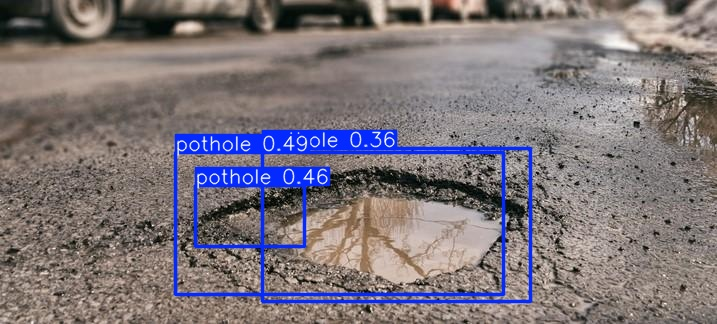

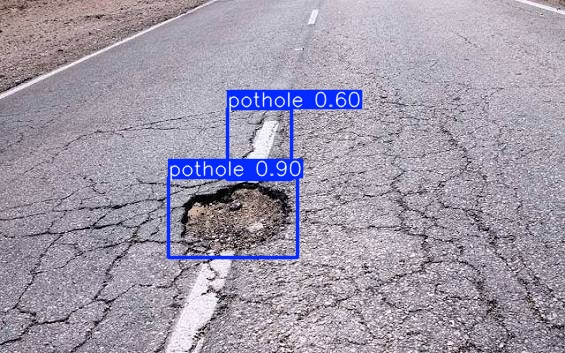

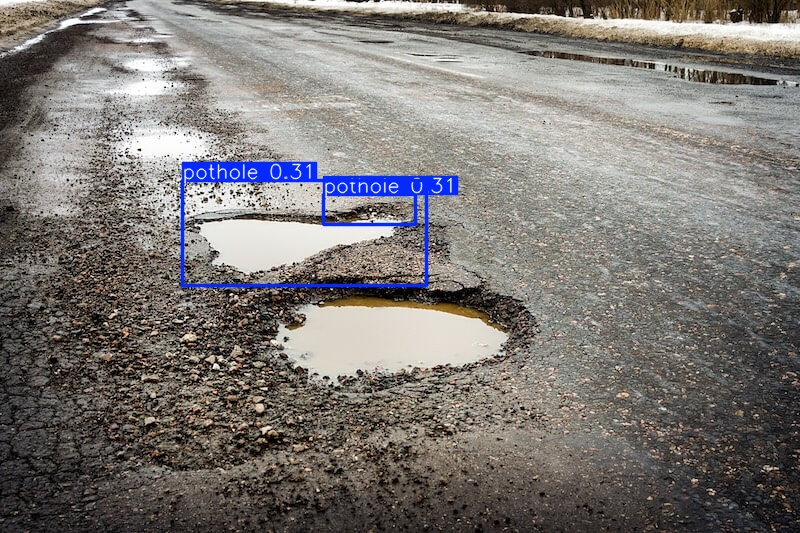

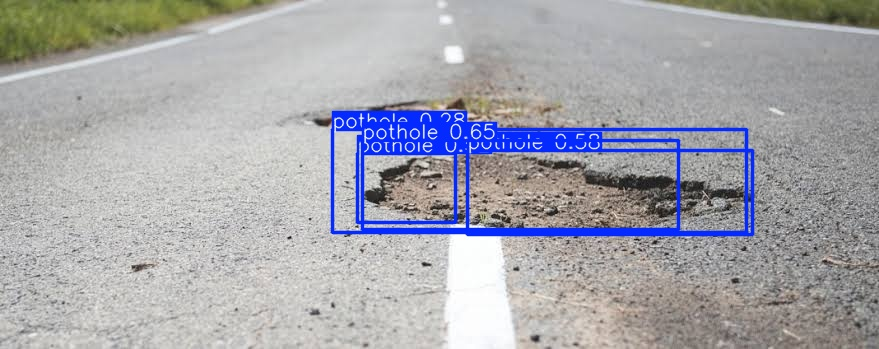

In [32]:
# ============================================================
# TEST V2 MODEL ON YOUR OWN PHOTOS
# ============================================================
BEST_V2 = f"{DRIVE_RUNS}/pothole_yolo11s_v2/weights/best.pt"
MY_TEST_DIR = f"{DRIVE_ROOT}/my_test_images"

os.chdir(HOME)
!yolo task=detect mode=predict \
      model={BEST_V2} \
      conf=0.25 \
      source={MY_TEST_DIR} \
      save=True \
      name=my_photos_predictions

import glob
from IPython.display import display, Image as IPyImage
pred_dirs = sorted(glob.glob(f'{HOME}/runs/detect/my_photos_predictions*/'))
if pred_dirs:
    for img in glob.glob(f'{pred_dirs[-1]}/*.jpg'):
        display(IPyImage(filename=img, width=640))

**Save Everything to Drive**

In [34]:
# ============================================================
# VERIFY V1 AND V2 ARE BOTH SAFE ON DRIVE (no copying needed)
# ============================================================
RUN_V1 = "pothole_yolo11s_v1"
RUN_V2 = "pothole_yolo11s_v2"

for run in [RUN_V1, RUN_V2]:
    best_path = f"{DRIVE_RUNS}/{run}/weights/best.pt"
    last_path = f"{DRIVE_RUNS}/{run}/weights/last.pt"
    print(f"\n📁 {run}")
    if os.path.exists(best_path):
        size_mb = os.path.getsize(best_path) / 1e6
        print(f"   ✅ best.pt found ({size_mb:.1f} MB)")
    else:
        print(f"   ❌ best.pt NOT found at {best_path}")
    if os.path.exists(last_path):
        print(f"   ✅ last.pt found")
    else:
        print(f"   ⚠️  last.pt not found")

print(f"\n🎉 Both models live independently on Drive:")
print(f"   V1: {DRIVE_RUNS}/{RUN_V1}/weights/best.pt")
print(f"   V2: {DRIVE_RUNS}/{RUN_V2}/weights/best.pt")
print(f"\n   To load V2 anytime:")
print(f"   from ultralytics import YOLO")
print(f"   model = YOLO('{DRIVE_RUNS}/{RUN_V2}/weights/best.pt')")
print(f"   results = model.predict('your_road_image.jpg', conf=0.25)")


📁 pothole_yolo11s_v1
   ❌ best.pt NOT found at /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v1/weights/best.pt
   ⚠️  last.pt not found

📁 pothole_yolo11s_v2
   ✅ best.pt found (19.2 MB)
   ✅ last.pt found

🎉 Both models live independently on Drive:
   V1: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v1/weights/best.pt
   V2: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v2/weights/best.pt

   To load V2 anytime:
   from ultralytics import YOLO
   model = YOLO('/content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v2/weights/best.pt')
   results = model.predict('your_road_image.jpg', conf=0.25)


In [39]:
# ============================================================
# RUN V2 MODEL ON YOUR UPLOADED PHOTOS — SAVE RESULTS TO DRIVE
# ============================================================
RUN_V2      = "pothole_yolo11s_v2"
BEST_V2     = f"{DRIVE_RUNS}/{RUN_V2}/weights/best.pt"
MY_TEST_DIR = f"{DRIVE_ROOT}/my_test_images"

assert os.path.exists(BEST_V2), f"❌ V2 weights not found at {BEST_V2}"
assert os.path.exists(MY_TEST_DIR), f"❌ Upload folder not found at {MY_TEST_DIR}"

os.chdir(HOME)
print(f"🔍 Running V2 detection — saving results DIRECTLY to Drive...\n")

!yolo task=detect mode=predict \
      model={BEST_V2} \
      conf=0.25 \
      source={MY_TEST_DIR} \
      save=True \
      project={DRIVE_ROOT}/predictions \
      name=v2_my_photos

print(f"\n✅ V2 results saved permanently to:")
print(f"   {DRIVE_ROOT}/predictions/v2_my_photos/")

🔍 Running V2 detection — saving results DIRECTLY to Drive...

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/4 /content/drive/MyDrive/PotholeAI/my_test_images/iStock-655985038.jpg: 384x800 3 potholes, 487.8ms
image 2/4 /content/drive/MyDrive/PotholeAI/my_test_images/images (2).jpg: 512x800 2 potholes, 646.6ms
image 3/4 /content/drive/MyDrive/PotholeAI/my_test_images/images (3).jpg: 320x800 4 potholes, 356.2ms
image 4/4 /content/drive/MyDrive/PotholeAI/my_test_images/pothole.jpeg: 544x800 2 potholes, 981.7ms
Speed: 5.1ms preprocess, 618.1ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 800)
Results saved to /content/drive/MyDrive/PotholeAI/predictions/v2_my_photos
💡 Learn more at https://docs.ultralytics.com/modes/predict

✅ V2 results saved permanently to:
   /content/drive/MyDrive/PotholeAI/predictions/v2_my_photos/


In [ ]:
# ============================================================
# DISPLAY V1 vs V2 PREDICTIONS SIDE BY SIDE
# ============================================================
from IPython.display import display, Image as IPyImage
import glob

for label, folder in [("V1", "v1_my_photos"), ("V2", "v2_my_photos")]:
    path = f"{DRIVE_ROOT}/predictions/{folder}"
    imgs = sorted(glob.glob(f"{path}/*.jpg"))
    print(f"\n{'='*40}\n{label} — {len(imgs)} images\n{'='*40}")
    for img in imgs:
        print(os.path.basename(img))
        display(IPyImage(filename=img, width=500))